# Library Imports

In [ ]:
import pandas as pd
import heapq
import copy
import time
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional
import seaborn as sns


# Data Loading

In [2]:
def Data_Load():
    file_path = "term_project_data.csv"
    df = pd.read_csv(file_path)
    df = df.T
    jobs_list = [{'p' if key == "processing_time" else 'r': int(value) for key, value in dict(job).items()} for job in dict(df).values()]
    jobs_list = [{**{'i': key}, **value} for key, value in enumerate(jobs_list)]
    return jobs_list

# Basic Function

In [3]:
def R(job, t):
    return max(t, job['r'])

def E(job, t):
    return R(job, t) + job['p']

def F(job_1, job_2, t):
    return (E(job_1, t) - job_1['r']) + (E(job_2, E(job_1, t)) - job_2['r'])

def Phi(K):
    if K:
        t = 0
        for job in K:
            t = E(job, t)
        return t
    else:
        return 0

def PRTF(job, t):
    return R(job, t) + E(job, t)

# Optimization Objective: Total Completion Time

In [4]:
def TCT_Objective(S):
    T = 0
    C_list = {}
    for job_segment in S:    
        job_id = job_segment['i']
        T = E(job_segment, T)
        C_list[job_id] = T
    return sum(C_list.values())

# Upper Bound: APRFT, EST

In [5]:
def PRTF_Algorithm(jobs, t=0):
    S = list()                     
    current_time = t               
    jobs_available = {job['i']: job for job in jobs}     
    while jobs_available:
        jobs_view = jobs_available.values()    
        if not jobs_view:
            break
        job = min(jobs_view, key=lambda x: PRTF(x, current_time) + x['r'] / 500)
        S.append(job)
        job_id = job['i']
        del jobs_available[job_id]             
        current_time = E(job, current_time)
    return S

In [6]:
def APRTF_Algorithm(jobs, t):
    S = []                                  
    current_time = t                        
    jobs_available = {job['i']: job for job in jobs} 
    while jobs_available:        
        jobs_view = jobs_available.values()
        if not jobs_view:
            break
        job_alpha = min(jobs_view, 
                        key=lambda x: PRTF(x, current_time) + x['r'] / 500)
        job_beta = min(jobs_view, 
                       key=lambda x: R(x, current_time) + x['p'] / 100)
        if job_alpha['r'] <= R(job_beta, current_time):
            job = job_alpha
        else:
            mu = len(jobs_available) - 2 if job_alpha != job_beta else len(jobs_available) - 1
            other_jobs = [j for j in jobs_view if j != job_alpha and j != job_beta]
            tau = min(other_jobs, key=lambda x: x['r'])['r'] if other_jobs else 500
            if F(job_beta, job_alpha, current_time) - F(job_alpha, job_beta, current_time) < \
               mu * min(R(job_alpha, current_time) - R(job_beta, current_time), 
                        E(job_beta, E(job_alpha, current_time)) - tau):
                job = job_beta
            else:
                job = job_alpha
        S.append(job)
        job_id = job['i']
        del jobs_available[job_id]     
        current_time = E(job, current_time)
    return S

In [7]:
import heapq

def EST_Algorithm(jobs, t):
    PQ = [] 
    for job in jobs:
        priority_tuple = (
            job['r'],   
            job['p'],   
            job['i'],   
            job         
        )        
        heapq.heappush(PQ, priority_tuple)
    S = [] 
    while PQ:
        _, _, _, job = heapq.heappop(PQ)
        S.append(job)
    return S

# Lower Bound: SRPT

In [8]:
def SRPT_Algorithm(K_c, t):
    jobs = []
    for job in copy.deepcopy(K_c):
        job['rem'] = job['p']
        jobs.append(job)

    jobs.sort(key=lambda x: x['r'])

    S = []                  
    ready_queue = []            
    time = t   
    jobs_idx = 0            
    current_job = None      
    
    while jobs_idx < len(jobs) and jobs[jobs_idx]['r'] <= time:
        job = jobs[jobs_idx]
        heapq.heappush(ready_queue, (job['rem'], job['i'], job)) 
        jobs_idx += 1
    if ready_queue:
        shortest_rem, _, current_job = heapq.heappop(ready_queue)

    while jobs_idx < len(jobs) or ready_queue or current_job:
        while jobs_idx < len(jobs) and jobs[jobs_idx]['r'] <= time:
            job = jobs[jobs_idx]
            heapq.heappush(ready_queue, (job['rem'], job['i'], job)) 
            jobs_idx += 1
        if ready_queue:
            shortest_rem, _, shortest_job = ready_queue[0] 
            if current_job is None or shortest_rem < current_job['rem']:
                if current_job is not None:
                    heapq.heappush(ready_queue, (current_job['rem'], current_job['i'], current_job))
                heapq.heappop(ready_queue)
                current_job = shortest_job
        if current_job is None:
            if jobs_idx < len(jobs):
                time = jobs[jobs_idx]['r']
            else:
                break 
        else:
            finish_time = time + current_job['rem']
            if jobs_idx < len(jobs):
                next_arrival_time = jobs[jobs_idx]['r']
                next_event_time = min(finish_time, next_arrival_time)
            else:
                next_event_time = finish_time
            execution_time = next_event_time - time
            S.append({'i': current_job['i'], 'p': execution_time, 'r': current_job['r']})
            current_job['rem'] -= execution_time
            time = next_event_time
            if current_job['rem'] <= 0:
                current_job = None
    return S

# Dominance Criteria

In [9]:
def Check_F_Active(K, job):
    job_i = K[-1]
    job_j = job
    K_i = K[:-1]
    delta_i = Phi(K_i)
    cond_1 = R(job_i, delta_i) < R(job_j, delta_i)
    cond_2 = PRTF(job_i, delta_i) <= PRTF(job_j, delta_i)
    return cond_1 or cond_2

def Check_Thm_AB(K_c, job, Phi_K):
    # Thm6 and Thm7
    job_i = job
    E_i = E(job_i, Phi_K)
    for job_j in K_c:
        if job_i == job_j:
            continue
        E_j = E(job_j, Phi_K)
        # Thm6
        if E_i >= E_j:
            lhs = E_i - E_j
            rhs = (job_i['p']-job_j['p']) * (len(K_c) -1)
            return lhs >= rhs
        # Thm7
        if E_i <= E_j:
            lhs = job_i['p']-job_j['p']
            rhs = (E_i-E_j) * (len(K_c))
            return lhs <= rhs
    return False

def Check_Thm_CD(K, K_c, job):
    # Thm9 and Thm10
    job_i = job
    for k, job_j in enumerate(K):
        delta_j = Phi(K[:k])
        E_i = E(job_i, delta_j)
        E_j = E(job_j, delta_j)
        # Thm9
        if E_i <= E_j:
            lhs = E_i - E_j
            rhs = (job_i['p']-job_j['p']) * (len(K_c))
            return lhs <= rhs
        # Thm10
        if job_i['p'] >= job_j['p']:
            lhs = job_i['p'] - job_j['p']
            rhs = (E_i-E_j) * (len(K)-k+2)
            return lhs >= rhs
    return False

# Branch and Bound

In [10]:
def BB_C(jobs):
    start_time = time.perf_counter()
    N = len(jobs)
    job_map = {job['i']: job for job in jobs}
    jobs_id_set = set(job['i'] for job in jobs)
    num_node_generated = 1
    num_node_considered = 1
    S = APRTF_Algorithm(jobs, 0)
    UB = TCT_Objective(S)
    LB = TCT_Objective(SRPT_Algorithm(jobs, 0))
    Root_Node = {
        'K': list(),
        'K_set': set()
    }
    PQ = [] 
    heapq.heappush(PQ, (LB, UB, num_node_generated, Root_Node))
    max_len_PQ = len(PQ)

    while PQ:
        max_len_PQ = len(PQ) if len(PQ) > max_len_PQ else max_len_PQ
        LB_current, _, _, Node = heapq.heappop(PQ)
        if LB_current > UB: 
            continue
        if LB_current == UB and len(Node['K']) < N:
            K_sequence = Node['K']
            K_set = Node['K_set']
            K_c_id_set = jobs_id_set - K_set
            K_c_sequence = [job_map[id] for id in K_c_id_set]
            Phi_K = Phi(K_sequence)
            S = K_sequence + APRTF_Algorithm(K_c_sequence, Phi_K)
            break
        K_c_id_set = jobs_id_set - Node['K_set']
        for job_id_next in K_c_id_set:
            num_node_generated += 1
            job_next = job_map[job_id_next]
            K_sequence_next = Node['K'] + [job_next]
            K_set_next = Node['K_set'] | {job_id_next}
            K_c_id_set_next = jobs_id_set - K_set_next
            K_c_sequence_next = [job_map[id] for id in K_c_id_set_next]
            Phi_K_next = Phi(K_sequence_next)
            if Node['K']:
                if not Check_F_Active(Node['K'], job_next):
                    continue
                if Check_Thm_AB(K_c_sequence_next, job_next, Phi(Node['K'])):
                    continue
                if Check_Thm_CD(Node['K'], [job_next]+K_c_sequence_next, job_next):
                    continue
            UB_next = TCT_Objective(K_sequence_next + APRTF_Algorithm(K_c_sequence_next, Phi_K_next))
            LB_next = TCT_Objective(K_sequence_next + SRPT_Algorithm(K_c_sequence_next, Phi_K_next))
            num_node_considered += 1
            Node_next = {
                        'K': K_sequence_next, 
                        'K_set': K_set_next,
                    }
            if len(Node_next['K']) == N:
                if LB_next < UB:
                    UB = LB_next
                    S = Node_next
            else:
                UB = min(UB, UB_next)
                heapq.heappush(PQ, (LB_next, UB_next, num_node_generated, Node_next))
    end_time = time.perf_counter()
    elapsed_time_sec = end_time - start_time
    Performance_Measures = dict()
    Performance_Measures['NC'] = num_node_considered
    Performance_Measures['NG'] = num_node_generated
    Performance_Measures['MaxSizePQ'] = max_len_PQ
    Performance_Measures['Time'] = f"{elapsed_time_sec:.3f}"
    return S, Performance_Measures

In [11]:
def BB_C_P(jobs):
    start_time = time.perf_counter()
    N = len(jobs)
    job_map = {job['i']: job for job in jobs}
    jobs_id_set = set(job['i'] for job in jobs)
    num_node_generated = 1
    num_node_considered = 1
    S = PRTF_Algorithm(jobs, 0)
    UB = TCT_Objective(S)
    LB = TCT_Objective(SRPT_Algorithm(jobs, 0))
    Root_Node = {
        'K': list(),
        'K_set': set()
    }
    PQ = [] 
    heapq.heappush(PQ, (LB, UB, num_node_generated, Root_Node))
    max_len_PQ = len(PQ)

    while PQ:
        max_len_PQ = len(PQ) if len(PQ) > max_len_PQ else max_len_PQ
        LB_current, _, _, Node = heapq.heappop(PQ)
        if LB_current > UB: 
            continue
        if LB_current == UB and len(Node['K']) < N:
            K_sequence = Node['K']
            K_set = Node['K_set']
            K_c_id_set = jobs_id_set - K_set
            K_c_sequence = [job_map[id] for id in K_c_id_set]
            Phi_K = Phi(K_sequence)
            S = K_sequence + PRTF_Algorithm(K_c_sequence, Phi_K)
            break
        K_c_id_set = jobs_id_set - Node['K_set']
        for job_id_next in K_c_id_set:
            num_node_generated += 1
            job_next = job_map[job_id_next]
            K_sequence_next = Node['K'] + [job_next]
            K_set_next = Node['K_set'] | {job_id_next}
            K_c_id_set_next = jobs_id_set - K_set_next
            K_c_sequence_next = [job_map[id] for id in K_c_id_set_next]
            Phi_K_next = Phi(K_sequence_next)
            if Node['K']:
                if not Check_F_Active(Node['K'], job_next):
                    continue
                if Check_Thm_AB(K_c_sequence_next, job_next, Phi(Node['K'])):
                    continue
                if Check_Thm_CD(Node['K'], [job_next]+K_c_sequence_next, job_next):
                    continue
            UB_next = TCT_Objective(K_sequence_next + PRTF_Algorithm(K_c_sequence_next, Phi_K_next))
            LB_next = TCT_Objective(K_sequence_next + SRPT_Algorithm(K_c_sequence_next, Phi_K_next))
            num_node_considered += 1
            Node_next = {
                        'K': K_sequence_next, 
                        'K_set': K_set_next,
                    }
            if len(Node_next['K']) == N:
                if LB_next < UB:
                    UB = LB_next
                    S = Node_next
            else:
                UB = min(UB, UB_next)
                heapq.heappush(PQ, (LB_next, UB_next, num_node_generated, Node_next))
    end_time = time.perf_counter()
    elapsed_time_sec = end_time - start_time
    Performance_Measures = dict()
    Performance_Measures['NC'] = num_node_considered
    Performance_Measures['NG'] = num_node_generated
    Performance_Measures['MaxSizePQ'] = max_len_PQ
    Performance_Measures['Time'] = f"{elapsed_time_sec:.3f}"
    return S, Performance_Measures

In [12]:
def BB_C_NH(jobs):
    start_time = time.perf_counter()
    N = len(jobs)
    job_map = {job['i']: job for job in jobs}
    jobs_id_set = set(job['i'] for job in jobs)
    num_node_generated = 1
    num_node_considered = 1
    S = EST_Algorithm(jobs, 0)
    UB = TCT_Objective(S)
    LB = TCT_Objective(SRPT_Algorithm(jobs, 0))
    Root_Node = {
        'K': list(),
        'K_set': set()
    }
    PQ = [] 
    heapq.heappush(PQ, (LB, UB, num_node_generated, Root_Node))
    max_len_PQ = len(PQ)

    while PQ:
        max_len_PQ = len(PQ) if len(PQ) > max_len_PQ else max_len_PQ
        LB_current, _, _, Node = heapq.heappop(PQ)
        if LB_current > UB: 
            continue
        if LB_current == UB and len(Node['K']) < N:
            K_sequence = Node['K']
            K_set = Node['K_set']
            K_c_id_set = jobs_id_set - K_set
            K_c_sequence = [job_map[id] for id in K_c_id_set]
            Phi_K = Phi(K_sequence)
            S = K_sequence + EST_Algorithm(K_c_sequence, Phi_K)
            break
        K_c_id_set = jobs_id_set - Node['K_set']
        for job_id_next in K_c_id_set:
            num_node_generated += 1
            job_next = job_map[job_id_next]
            K_sequence_next = Node['K'] + [job_next]
            K_set_next = Node['K_set'] | {job_id_next}
            K_c_id_set_next = jobs_id_set - K_set_next
            K_c_sequence_next = [job_map[id] for id in K_c_id_set_next]
            Phi_K_next = Phi(K_sequence_next)
            if Node['K']:
                if not Check_F_Active(Node['K'], job_next):
                    continue
                if Check_Thm_AB(K_c_sequence_next, job_next, Phi(Node['K'])):
                    continue
                if Check_Thm_CD(Node['K'], [job_next]+K_c_sequence_next, job_next):
                    continue
            UB_next = TCT_Objective(K_sequence_next + EST_Algorithm(K_c_sequence_next, Phi_K_next))
            LB_next = TCT_Objective(K_sequence_next + SRPT_Algorithm(K_c_sequence_next, Phi_K_next))
            num_node_considered += 1
            Node_next = {
                        'K': K_sequence_next, 
                        'K_set': K_set_next,
                    }
            if len(Node_next['K']) == N:
                if LB_next < UB:
                    UB = LB_next
                    S = Node_next
            else:
                UB = min(UB, UB_next)
                heapq.heappush(PQ, (LB_next, UB_next, num_node_generated, Node_next))
    end_time = time.perf_counter()
    elapsed_time_sec = end_time - start_time
    Performance_Measures = dict()
    Performance_Measures['NC'] = num_node_considered
    Performance_Measures['NG'] = num_node_generated
    Performance_Measures['MaxSizePQ'] = max_len_PQ
    Performance_Measures['Time'] = f"{elapsed_time_sec:.3f}"
    return S, Performance_Measures

In [13]:
def BB_C_ND(jobs):
    start_time = time.perf_counter()
    N = len(jobs)
    job_map = {job['i']: job for job in jobs}
    jobs_id_set = set(job['i'] for job in jobs)
    num_node_generated = 1
    num_node_considered = 1
    S = APRTF_Algorithm(jobs, 0)
    UB = TCT_Objective(S)
    LB = TCT_Objective(SRPT_Algorithm(jobs, 0))
    Root_Node = {
        'K': list(),
        'K_set': set()
    }
    PQ = [] 
    heapq.heappush(PQ, (LB, UB, num_node_generated, Root_Node))
    max_len_PQ = len(PQ)

    while PQ:
        max_len_PQ = len(PQ) if len(PQ) > max_len_PQ else max_len_PQ
        LB_current, _, _, Node = heapq.heappop(PQ)
        if LB_current > UB: 
            continue
        if LB_current == UB and len(Node['K']) < N:
            K_sequence = Node['K']
            K_set = Node['K_set']
            K_c_id_set = jobs_id_set - K_set
            K_c_sequence = [job_map[id] for id in K_c_id_set]
            Phi_K = Phi(K_sequence)
            S = K_sequence + APRTF_Algorithm(K_c_sequence, Phi_K)
            break
        K_c_id_set = jobs_id_set - Node['K_set']
        for job_id_next in K_c_id_set:
            num_node_generated += 1
            job_next = job_map[job_id_next]
            K_sequence_next = Node['K'] + [job_next]
            K_set_next = Node['K_set'] | {job_id_next}
            K_c_id_set_next = jobs_id_set - K_set_next
            K_c_sequence_next = [job_map[id] for id in K_c_id_set_next]
            Phi_K_next = Phi(K_sequence_next)
            # if Node['K']:
            #     if not Check_F_Active(Node['K'], job_next):
            #         continue
            #     if Check_Thm_AB(K_c_sequence_next, job_next, Phi(Node['K'])):
            #         continue
            #     if Check_Thm_CD(Node['K'], [job_next]+K_c_sequence_next, job_next):
            #         continue
            UB_next = TCT_Objective(K_sequence_next + APRTF_Algorithm(K_c_sequence_next, Phi_K_next))
            LB_next = TCT_Objective(K_sequence_next + SRPT_Algorithm(K_c_sequence_next, Phi_K_next))
            num_node_considered += 1
            Node_next = {
                        'K': K_sequence_next, 
                        'K_set': K_set_next,
                    }
            if len(Node_next['K']) == N:
                if LB_next < UB:
                    UB = LB_next
                    S = Node_next
            else:
                UB = min(UB, UB_next)
                heapq.heappush(PQ, (LB_next, UB_next, num_node_generated, Node_next))
    end_time = time.perf_counter()
    elapsed_time_sec = end_time - start_time
    Performance_Measures = dict()
    Performance_Measures['NC'] = num_node_considered
    Performance_Measures['NG'] = num_node_generated
    Performance_Measures['MaxSizePQ'] = max_len_PQ
    Performance_Measures['Time'] = f"{elapsed_time_sec:.3f}"
    return S, Performance_Measures

In [14]:
def BB_C_NA(jobs):
    start_time = time.perf_counter()
    N = len(jobs)
    job_map = {job['i']: job for job in jobs}
    jobs_id_set = set(job['i'] for job in jobs)
    num_node_generated = 1
    num_node_considered = 1
    S = EST_Algorithm(jobs, 0)
    UB = TCT_Objective(S)
    LB = TCT_Objective(SRPT_Algorithm(jobs, 0))
    Root_Node = {
        'K': list(),
        'K_set': set()
    }
    PQ = [] 
    heapq.heappush(PQ, (LB, UB, num_node_generated, Root_Node))
    max_len_PQ = len(PQ)

    while PQ:
        max_len_PQ = len(PQ) if len(PQ) > max_len_PQ else max_len_PQ
        LB_current, _, _, Node = heapq.heappop(PQ)
        if LB_current > UB: 
            continue
        if LB_current == UB and len(Node['K']) < N:
            K_sequence = Node['K']
            K_set = Node['K_set']
            K_c_id_set = jobs_id_set - K_set
            K_c_sequence = [job_map[id] for id in K_c_id_set]
            Phi_K = Phi(K_sequence)
            S = K_sequence + EST_Algorithm(K_c_sequence, Phi_K)
            break
        K_c_id_set = jobs_id_set - Node['K_set']
        for job_id_next in K_c_id_set:
            num_node_generated += 1
            job_next = job_map[job_id_next]
            K_sequence_next = Node['K'] + [job_next]
            K_set_next = Node['K_set'] | {job_id_next}
            K_c_id_set_next = jobs_id_set - K_set_next
            K_c_sequence_next = [job_map[id] for id in K_c_id_set_next]
            Phi_K_next = Phi(K_sequence_next)
            # if Node['K']:
            #     if not Check_F_Active(Node['K'], job_next):
            #         continue
            #     if Check_Thm_AB(K_c_sequence_next, job_next, Phi(Node['K'])):
            #         continue
            #     if Check_Thm_CD(Node['K'], [job_next]+K_c_sequence_next, job_next):
            #         continue
            UB_next = TCT_Objective(K_sequence_next + EST_Algorithm(K_c_sequence_next, Phi_K_next))
            LB_next = TCT_Objective(K_sequence_next + SRPT_Algorithm(K_c_sequence_next, Phi_K_next))
            num_node_considered += 1
            Node_next = {
                        'K': K_sequence_next, 
                        'K_set': K_set_next,
                    }
            if len(Node_next['K']) == N:
                if LB_next < UB:
                    UB = LB_next
                    S = Node_next
            else:
                UB = min(UB, UB_next)
                heapq.heappush(PQ, (LB_next, UB_next, num_node_generated, Node_next))
    end_time = time.perf_counter()
    elapsed_time_sec = end_time - start_time
    Performance_Measures = dict()
    Performance_Measures['NC'] = num_node_considered
    Performance_Measures['NG'] = num_node_generated
    Performance_Measures['MaxSizePQ'] = max_len_PQ
    Performance_Measures['Time'] = f"{elapsed_time_sec:.3f}"
    return S, Performance_Measures

# Main

In [15]:
jobs_list = list()
jobs_list.append({'i': 1, 'p': 5, 'r': 0})
jobs_list.append({'i': 2, 'p': 2, 'r': 0})
jobs_list.append({'i': 3, 'p': 2, 'r': 3})
jobs_list.append({'i': 4, 'p': 3, 'r': 4})
jobs_list.append({'i': 5, 'p': 4, 'r': 6})
jobs_list.append({'i': 6, 'p': 3, 'r': 7})
jobs_list.append({'i': 7, 'p': 1, 'r': 9})
jobs_list.append({'i': 8, 'p': 4, 'r': 13})
jobs_list.append({'i': 9, 'p': 6, 'r': 16})
jobs_list.append({'i': 10, 'p': 1, 'r': 19})

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
print(1+sum(range(1, 11)))
S, Performance_Measures = BB_C(jobs_list)
for job in S:
    print(job)
print(TCT_Objective(S))

154
150
56
{'i': 2, 'p': 2, 'r': 0}
{'i': 3, 'p': 2, 'r': 3}
{'i': 4, 'p': 3, 'r': 4}
{'i': 6, 'p': 3, 'r': 7}
{'i': 7, 'p': 1, 'r': 9}
{'i': 5, 'p': 4, 'r': 6}
{'i': 8, 'p': 4, 'r': 13}
{'i': 10, 'p': 1, 'r': 19}
{'i': 1, 'p': 5, 'r': 0}
{'i': 9, 'p': 6, 'r': 16}
153


In [16]:
jobs_list = list()
jobs_list.append({'i': 1, 'p': 5, 'r': 0})
jobs_list.append({'i': 2, 'p': 2, 'r': 0})
jobs_list.append({'i': 3, 'p': 2, 'r': 3})
jobs_list.append({'i': 4, 'p': 3, 'r': 4})
jobs_list.append({'i': 5, 'p': 4, 'r': 6})
jobs_list.append({'i': 6, 'p': 3, 'r': 7})
jobs_list.append({'i': 7, 'p': 1, 'r': 9})
jobs_list.append({'i': 8, 'p': 4, 'r': 13})
jobs_list.append({'i': 9, 'p': 6, 'r': 16})
jobs_list.append({'i': 10, 'p': 1, 'r': 19})

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
print(1+sum(range(1, 11)))
S, Performance_Measures = BB_C_P(jobs_list)
for job in S:
    print(job)
print(TCT_Objective(S))

154
150
56
{'i': 2, 'p': 2, 'r': 0}
{'i': 3, 'p': 2, 'r': 3}
{'i': 4, 'p': 3, 'r': 4}
{'i': 6, 'p': 3, 'r': 7}
{'i': 7, 'p': 1, 'r': 9}
{'i': 5, 'p': 4, 'r': 6}
{'i': 8, 'p': 4, 'r': 13}
{'i': 10, 'p': 1, 'r': 19}
{'i': 1, 'p': 5, 'r': 0}
{'i': 9, 'p': 6, 'r': 16}
153


In [17]:
jobs_list = Data_Load()
n = 75
jobs_list = jobs_list[:n+1]

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
S, Performance_Measures = BB_C(jobs_list)
print(Performance_Measures)
print("="*60)
print(TCT_Objective(S))

103151
102528
{'NC': 8344, 'NG': 10285, 'MaxSizePQ': 8181, 'Time': '12.975'}
102608


In [18]:
jobs_list = Data_Load()
n = 70
jobs_list = jobs_list[:n+1]

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
S, Performance_Measures = BB_C_ND(jobs_list)
print(Performance_Measures)
print("="*60)
print(TCT_Objective(S))

89470
88860
{'NC': 5031, 'NG': 5031, 'MaxSizePQ': 4953, 'Time': '8.232'}
88921


In [19]:
jobs_list = Data_Load()
n = 70
jobs_list = jobs_list[:n+1]

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
S, Performance_Measures = BB_C_P(jobs_list)
print(Performance_Measures)
print("="*60)
print(TCT_Objective(S))

89470
88860
{'NC': 1093, 'NG': 1828, 'MaxSizePQ': 1065, 'Time': '1.363'}
88921


In [20]:
jobs_list = Data_Load()
n = 72
jobs_list = jobs_list[:n+1]

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
S, Performance_Measures = BB_C_NA(jobs_list)
print(Performance_Measures)
print("="*60)
print(TCT_Objective(S))

95724
95102
{'NC': 7134, 'NG': 7134, 'MaxSizePQ': 6997, 'Time': '1.799'}
95164


In [21]:
79
{'NC': 38990, 'NG': 56999, 'MaxSizePQ': 38321, 'Time': '103.839'} 
179550


179550

# Some Figure For Presentation

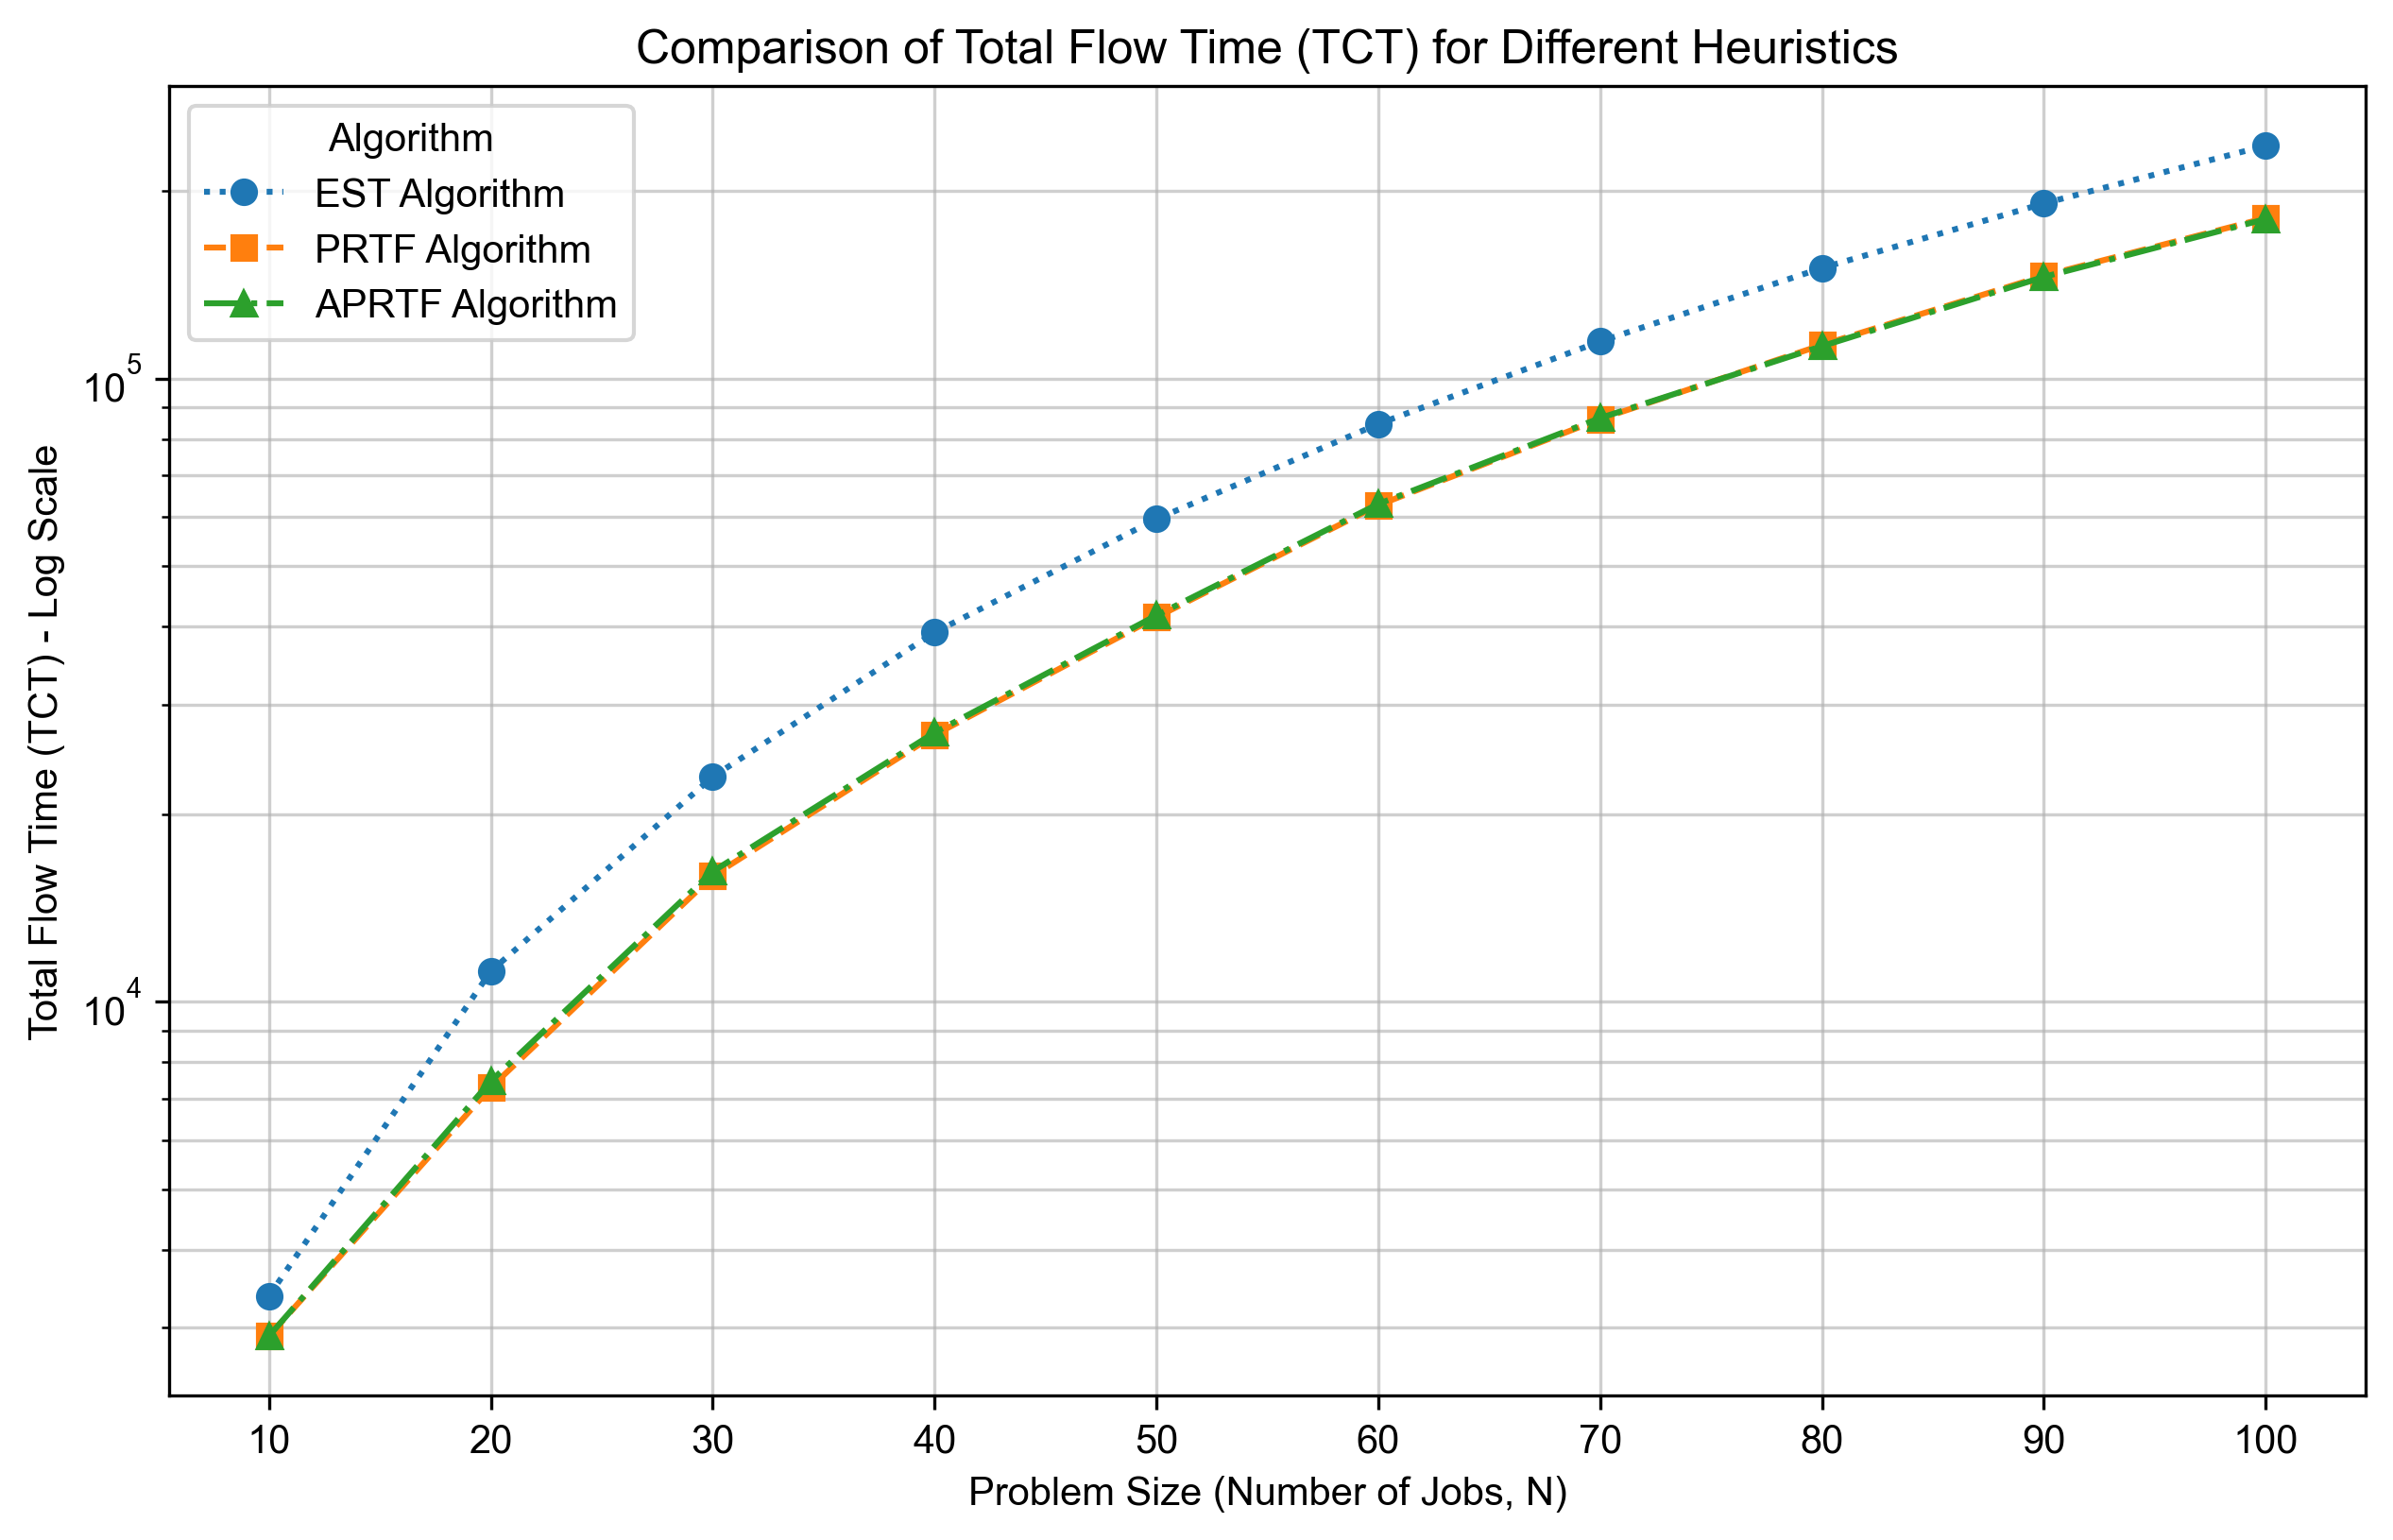

In [83]:
import matplotlib.pyplot as plt

jobs_list = Data_Load()
x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
y_e = []
y_p = []
y_a = []

for xx in x:
    current_jobs = jobs_list[:xx]
    y_e.append(TCT_Objective(EST_Algorithm(current_jobs, 0)))
    y_p.append(TCT_Objective(PRTF_Algorithm(current_jobs, 0)))
    y_a.append(TCT_Objective(APRTF_Algorithm(current_jobs, 0)))

plt.figure(figsize=(10, 6), dpi=300)
plt.yscale('log')
plt.plot(x, y_e, 
         label='EST Algorithm', 
         marker='o', 
         linestyle=':', 
         linewidth=1.5)
plt.plot(x, y_p, 
         label='PRTF Algorithm', 
         marker='s', 
         linestyle='--', 
         linewidth=1.5)
plt.plot(x, y_a, 
         label='APRTF Algorithm', 
         marker='^', 
         linestyle='-.', 
         linewidth=1.5)                    
plt.title('Comparison of Total Flow Time (TCT) for Different Heuristics')
plt.xlabel('Problem Size (Number of Jobs, N)')
plt.ylabel('Total Flow Time (TCT) - Log Scale')
plt.legend(title='Algorithm', loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.xticks(x)
path = 'result_fig/TCT_Compare.png'
plt.savefig(path)
plt.show()

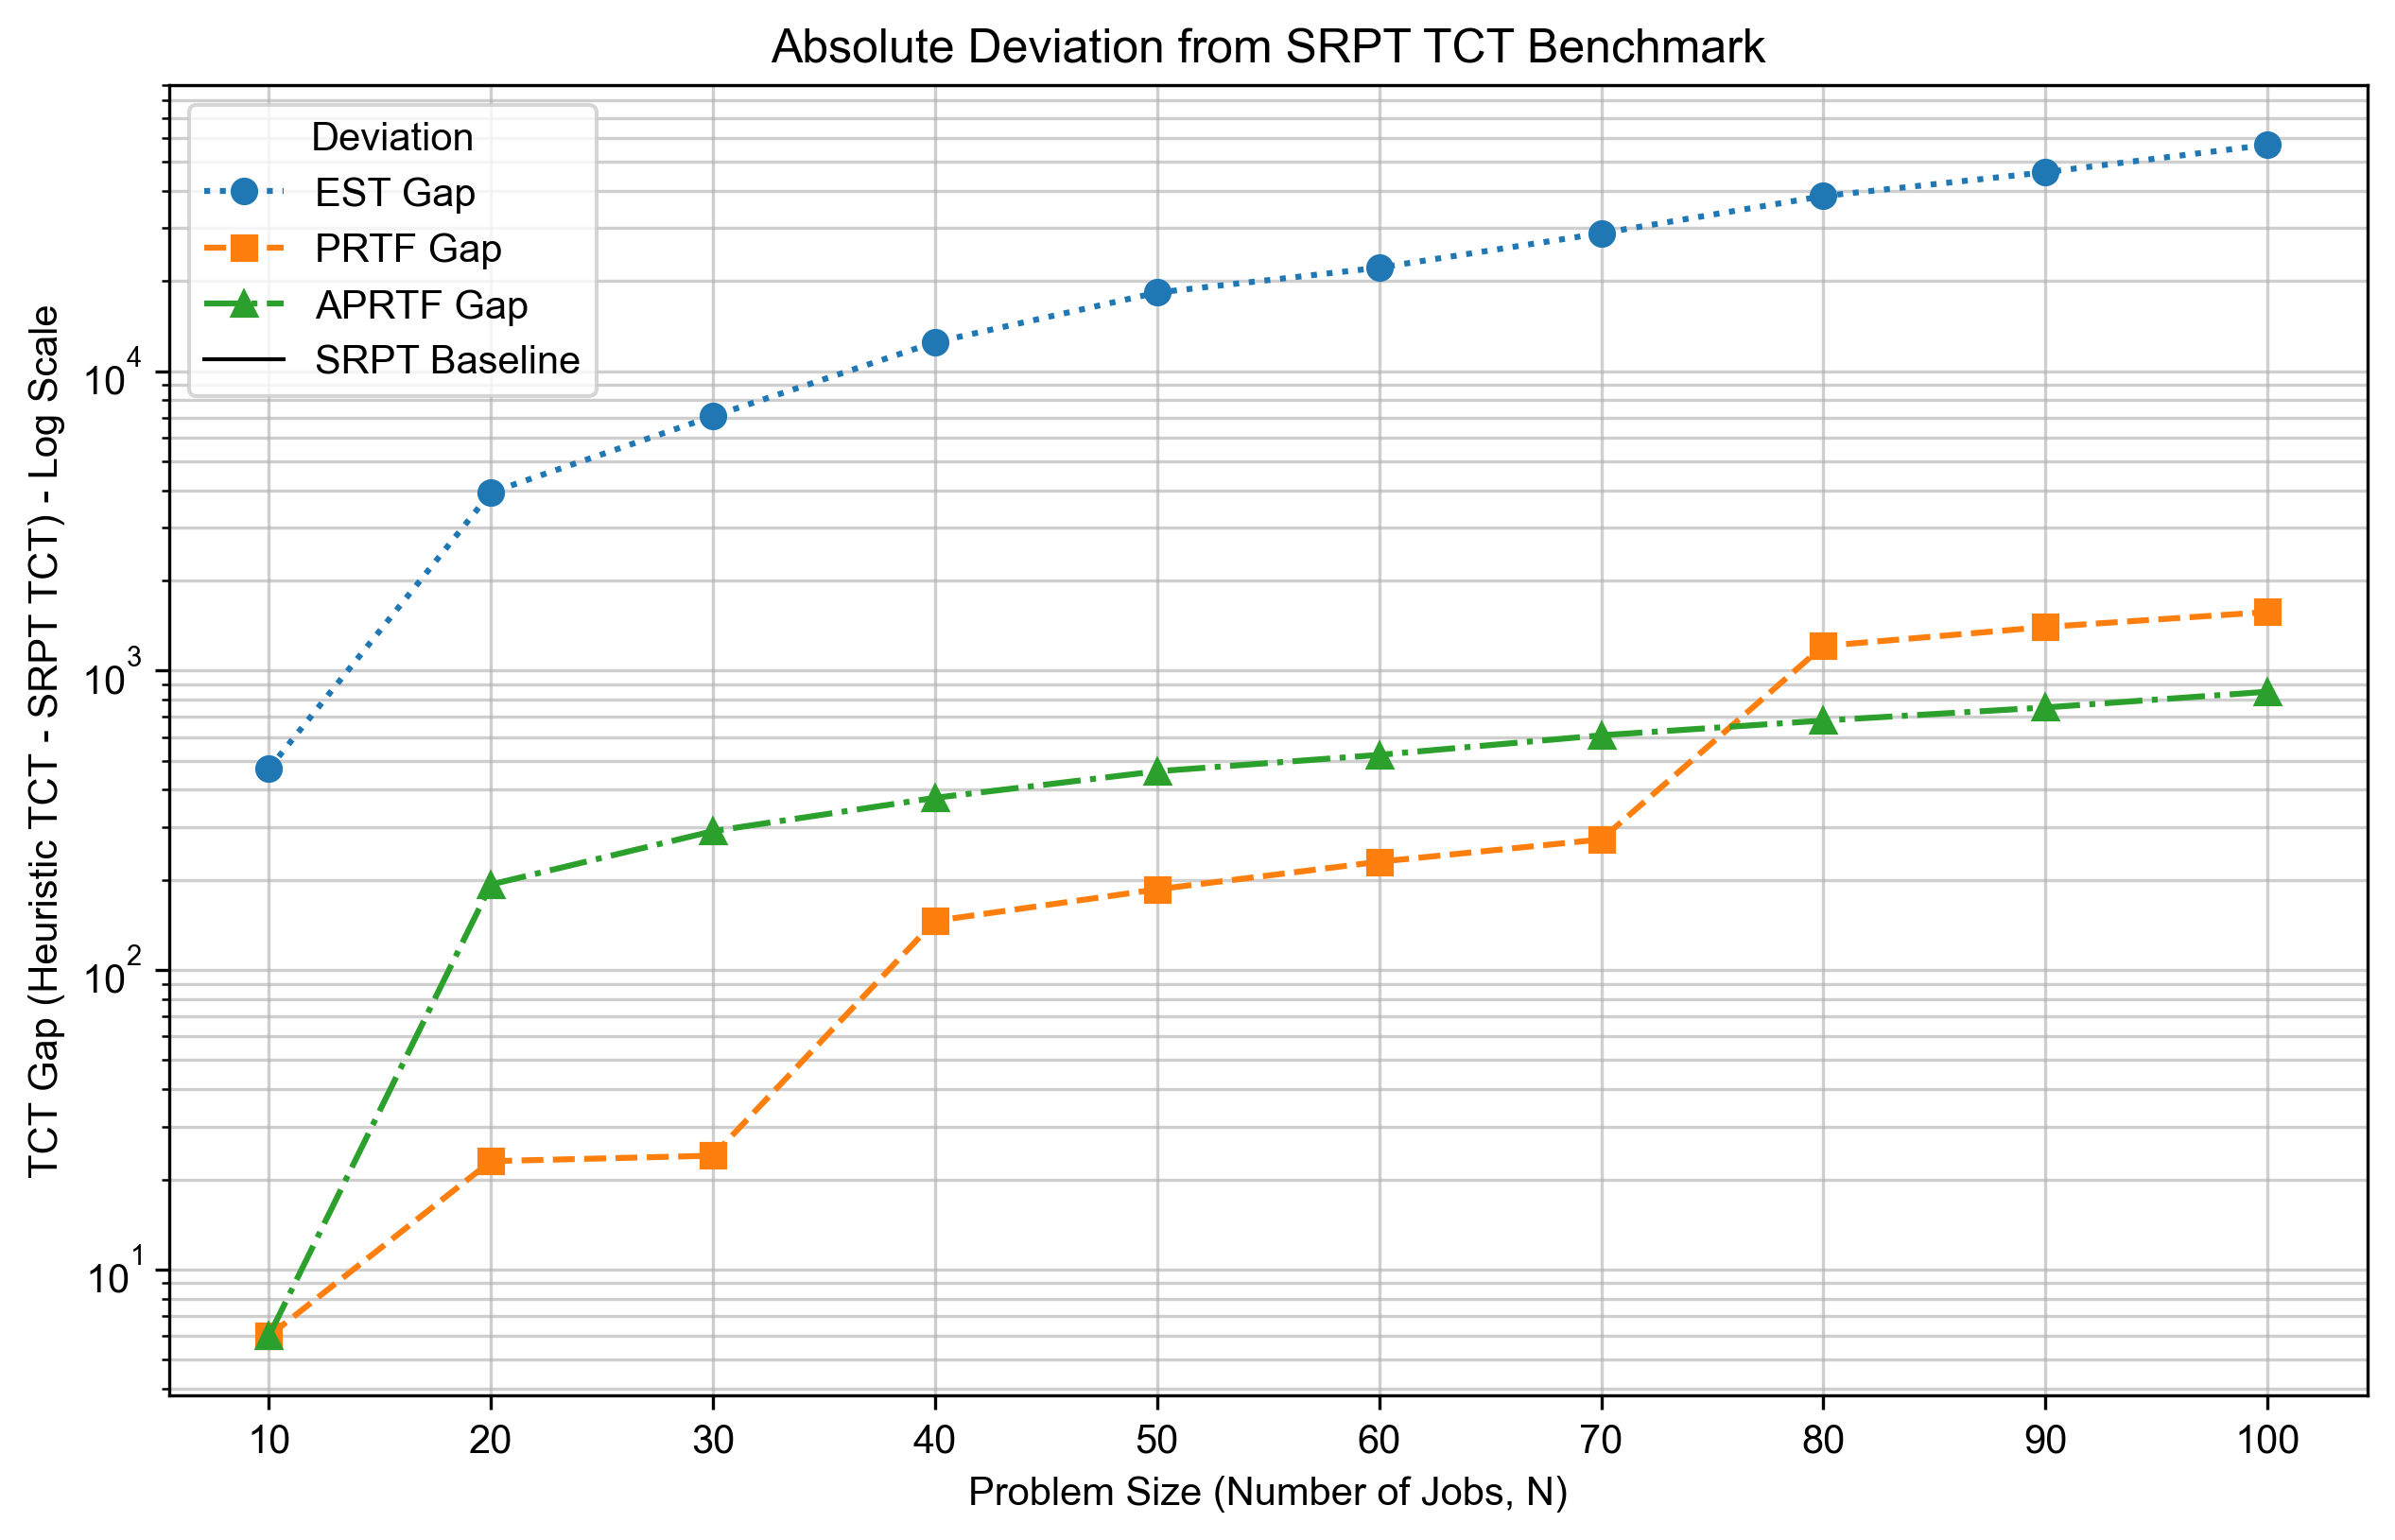

In [ ]:
jobs_list = Data_Load()
x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
y_e = []
y_p = []
y_a = []
y_s = []

for xx in x:
    current_jobs = jobs_list[:xx]
    y_e.append(TCT_Objective(EST_Algorithm(current_jobs, 0)))
    y_p.append(TCT_Objective(PRTF_Algorithm(current_jobs, 0)))
    y_a.append(TCT_Objective(APRTF_Algorithm(current_jobs, 0)))
    y_s.append(TCT_Objective(SRPT_Algorithm(current_jobs, 0)))

y_e_np = np.array(y_e)
y_p_np = np.array(y_p)
y_a_np = np.array(y_a)
y_s_np = np.array(y_s)

gap_e = y_e_np - y_s_np   
gap_p = y_p_np - y_s_np   
gap_a = y_a_np - y_s_np   

plt.figure(figsize=(10, 6), dpi=300)
plt.yscale('log') 

plt.title('Absolute Deviation from SRPT TCT Benchmark')
plt.xlabel('Problem Size (Number of Jobs, N)')
plt.ylabel('TCT Gap (Heuristic TCT - SRPT TCT) - Log Scale')

plt.plot(x, gap_e, 
         label='EST Gap', 
         marker='o', 
         linestyle=':', 
         linewidth=1.5)

plt.plot(x, gap_p, 
         label='PRTF Gap', 
         marker='s', 
         linestyle='--', 
         linewidth=1.5)

plt.plot(x, gap_a, 
         label='APRTF Gap', 
         marker='^', 
         linestyle='-.', 
         linewidth=1.5)

plt.axhline(0, color='black', linestyle='-', linewidth=1.0, label='SRPT Baseline')

plt.legend(title='Deviation', loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.xticks(x)
path = 'result_fig/TCT_SRPT_Gap.png'
plt.savefig(path)
plt.show()

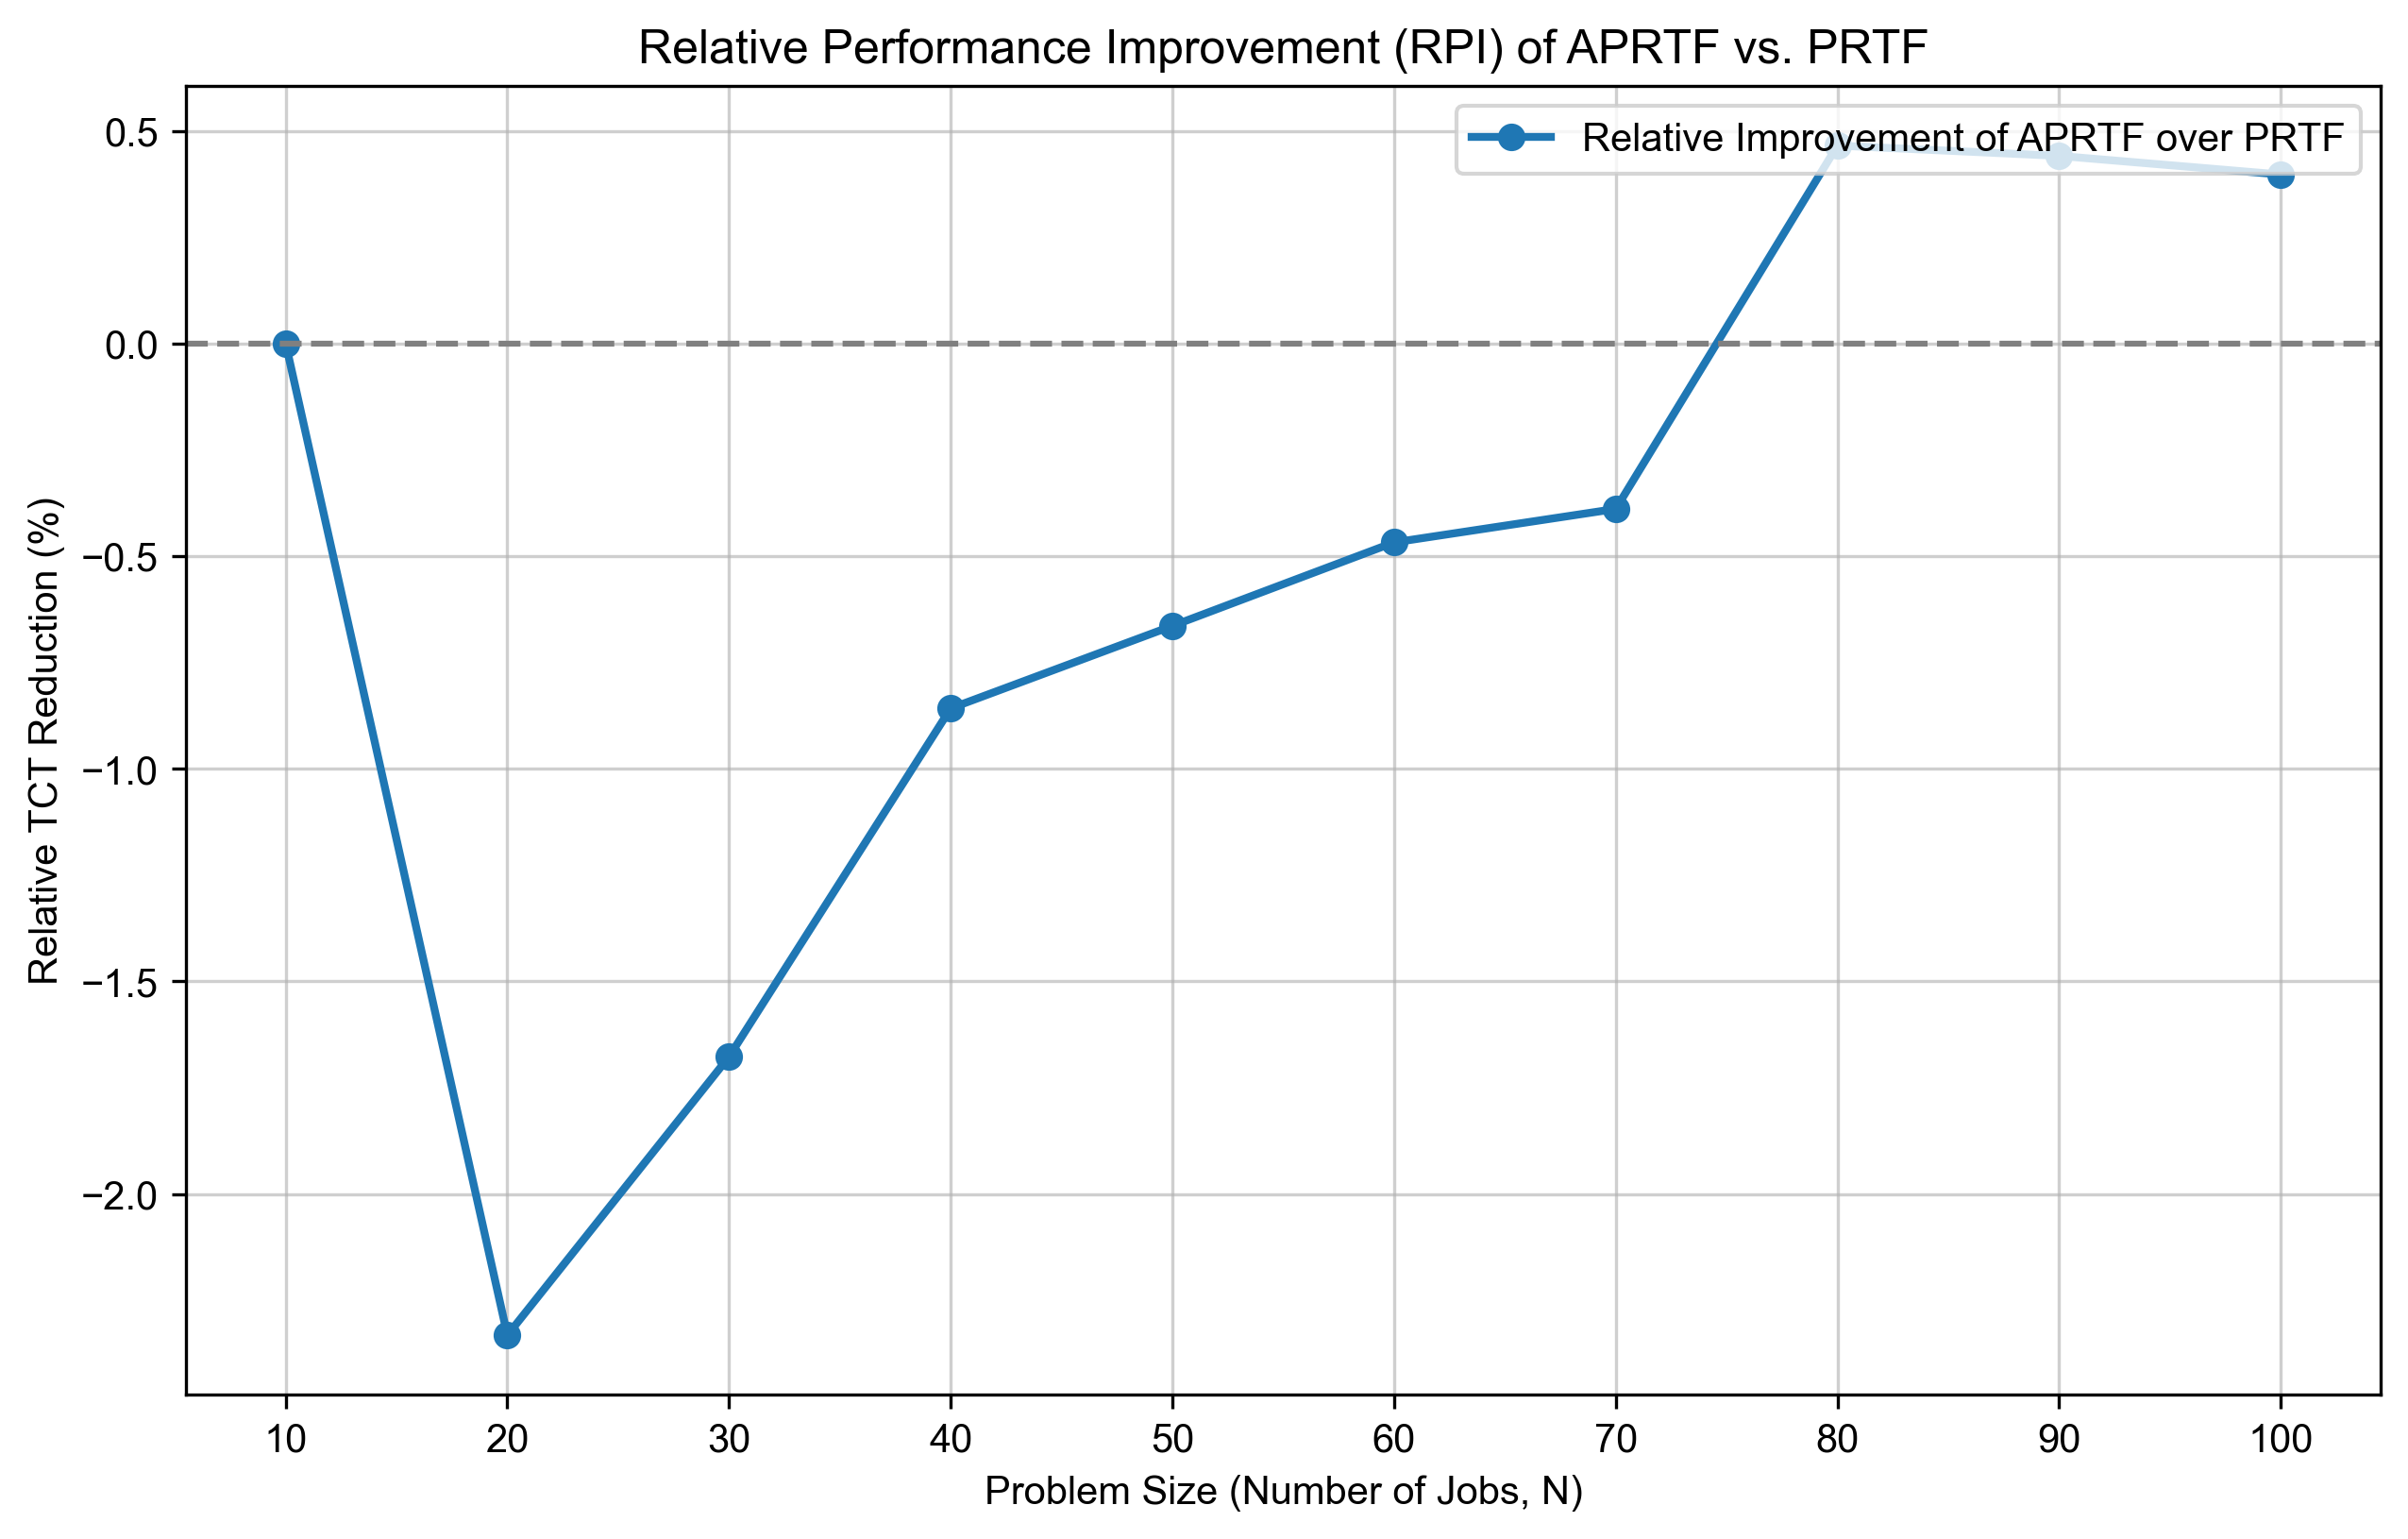

In [106]:
rpi_values = [( (y_p[i] - y_a[i]) / y_p[i] ) * 100 for i in range(len(x))]

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(x, rpi_values, 
         label='Relative Improvement of APRTF over PRTF', 
         marker='o',        
         linestyle='-', 
         linewidth=2)
plt.title('Relative Performance Improvement (RPI) of APRTF vs. PRTF')
plt.xlabel('Problem Size (Number of Jobs, N)')
plt.ylabel('Relative TCT Reduction (%)')
plt.axhline(0, color='gray', linestyle='--') 
plt.legend(loc='upper right')
plt.grid(True, which="major", ls="-", alpha=0.6)
plt.xticks(x)
path = 'result_fig/APRTF_RPI.png'
plt.savefig(path)
plt.show()

In [71]:
jobs_list = Data_Load()

x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
y_e = []
y_p = []
y_a = []
y_s = []

for xx in x:
    current_jobs = jobs_list[:xx]
    y_e.append(TCT_Objective(EST_Algorithm(current_jobs, 0)))
    y_p.append(TCT_Objective(PRTF_Algorithm(current_jobs, 0)))
    y_a.append(TCT_Objective(APRTF_Algorithm(current_jobs, 0)))
    y_s.append(TCT_Objective(SRPT_Algorithm(current_jobs, 0))) 

y_e_np = np.array(y_e)
y_p_np = np.array(y_p)
y_a_np = np.array(y_a)
y_s_np = np.array(y_s)

rpi_values = ((y_p_np - y_a_np) / y_p_np) * 100
gap_a_vs_s = y_a_np - y_s_np 
data = {
    'Problem Size (N)': x,
    'TCT_SRPT': y_s,
    'TCT_EST': y_e,
    'TCT_PRTF': y_p,
    'TCT_APRTF': y_a,
    'RPI (%)': rpi_values,  
    'Gap (A - S)': gap_a_vs_s 
}

df = pd.DataFrame(data)

df_display = df.copy()

df_display['RPI (%)'] = df_display['RPI (%)'].round(2).astype(str) + '%'
df_display['Gap (A - S)'] = df_display['Gap (A - S)'].round(2).astype(str)

for col in ['TCT_SRPT', 'TCT_EST', 'TCT_PRTF', 'TCT_APRTF']:
    df_display[col] = df_display[col].apply(lambda x: f'{int(x):,}')

print("="*110)
print('Heuristic Performance Analysis for Total Completion Time')
print("="*110)
print(df_display.to_markdown(index=False))
print("="*110)

path = 'result_csv/heuristic_performance_data.csv'
df_display.to_csv(path)

Heuristic Performance Analysis for Total Completion Time
|   Problem Size (N) | TCT_SRPT   | TCT_EST   | TCT_PRTF   | TCT_APRTF   | RPI (%)   |   Gap (A - S) |
|-------------------:|:-----------|:----------|:-----------|:------------|:----------|--------------:|
|                 10 | 2,904      | 3,374     | 2,910      | 2,910       | 0.0%      |             6 |
|                 20 | 7,267      | 11,202    | 7,290      | 7,460       | -2.33%    |           193 |
|                 30 | 15,896     | 22,967    | 15,920     | 16,187      | -1.68%    |           291 |
|                 40 | 26,662     | 39,152    | 26,808     | 27,038      | -0.86%    |           376 |
|                 50 | 41,225     | 59,516    | 41,411     | 41,686      | -0.66%    |           461 |
|                 60 | 62,408     | 84,560    | 62,638     | 62,931      | -0.47%    |           523 |
|                 70 | 85,833     | 114,700   | 86,106     | 86,441      | -0.39%    |           608 |
|               

In [70]:
jobs_list = Data_Load()
N_TEST = 70
current_jobs = jobs_list[:N_TEST+1]

BB_list = [BB_C, BB_C_NH, BB_C_ND, BB_C_NA]
y_nc = []
y_ng = []
y_max_PQ = []
y_time = []

for BB_Algorithm in BB_list:
    _, Performance_Measures = BB_Algorithm(current_jobs)
    y_nc.append(Performance_Measures['NC'])
    y_ng.append(Performance_Measures['NG'])
    y_max_PQ.append(Performance_Measures['MaxSizePQ'])
    y_time.append(Performance_Measures['Time'])

y_algorithm = ['BB_C', 'BB_C-H', 'BB_C-D', 'BB_C-A']
y_nc_np = np.array(y_nc)
y_ng_np = np.array(y_ng)
y_max_PQ_np = np.array(y_max_PQ)
y_time_np = np.array(y_time)

data = {
    'Algorithms': y_algorithm,
    'Number of Nodes Considered': y_nc_np,
    'Number of Nodes Generated': y_ng_np,
    'Maximal Number of Nodes in the List': y_max_PQ_np,
    'Computation Time': y_time_np
}

df = pd.DataFrame(data)

df_display = df.copy()

def display_dataframe_as_image(df_to_draw: pd.DataFrame, 
                               filename: Optional[str] = None, 
                               title: str = 'Scheduling Algorithm Results Comparison'): 
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize=(14, 6), dpi=300) 
    ax.axis('off')
    ax.axis('tight')
    
    table = ax.table(
        cellText=df_to_draw.values,  
        colLabels=df_to_draw.columns,
        cellLoc='center',
        loc='center', 
        colColours=['#f0f0f0'] * len(df_to_draw.columns) 
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    
    ax.set_title(title, y=1.0, fontsize=14, fontweight='bold')
    
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Image saved to: {filename}")
    plt.show() 

print("="*150)
print(f'Performance Comparison for N={N_TEST} Jobs')
print("="*150)
print(df_display.to_markdown(index=False))
print("="*150)
path = 'result_csv/algorithm_performance_data_70.csv'
df_display.to_csv(path)

Performance Comparison for N=70 Jobs
| Algorithms   |   Number of Nodes Considered |   Number of Nodes Generated |   Maximal Number of Nodes in the List |   Computation Time |
|:-------------|-----------------------------:|----------------------------:|--------------------------------------:|-------------------:|
| BB_C         |                         1093 |                        1828 |                                  1065 |              1.845 |
| BB_C-H       |                         2866 |                        3652 |                                  2781 |              0.64  |
| BB_C-D       |                         5031 |                        5031 |                                  4953 |              8.076 |
| BB_C-A       |                         6855 |                        6855 |                                  6720 |              1.669 |


In [ ]:
jobs_list = Data_Load()

TEST_list = list(range(10, 71, 10))
BB_list = [BB_C, BB_C_NH, BB_C_ND, BB_C_NA]
y_algorithm = []
y_js = []
y_nc = []
y_ng = []
y_max_PQ = []
y_time = []

for BB_Algorithm in BB_list:
    for N_TEST in TEST_list:
        if BB_Algorithm == BB_C:
            y_algorithm.append('BB_C')
        elif BB_Algorithm == BB_C_NH:
            y_algorithm.append('BB_C-H')
        elif BB_Algorithm == BB_C_ND:
            y_algorithm.append('BB_C-D')
        else:
            y_algorithm.append('BB_C-A')
        current_jobs = jobs_list[:N_TEST+1]
        _, Performance_Measures = BB_Algorithm(current_jobs)
        y_js.append(N_TEST)
        y_nc.append(Performance_Measures['NC'])
        y_ng.append(Performance_Measures['NG'])
        y_max_PQ.append(Performance_Measures['MaxSizePQ'])
        y_time.append(Performance_Measures['Time'])

y_nc_np = np.array(y_nc)
y_ng_np = np.array(y_ng)
y_max_PQ_np = np.array(y_max_PQ)
y_time_np = np.array(y_time)

data = {
    'Algorithms': y_algorithm,
    'Problem Size': y_js,
    'Number of Nodes Considered': y_nc_np,
    'Number of Nodes Generated': y_ng_np,
    'Maximal Number of Nodes in the List': y_max_PQ_np,
    'Computation Time': y_time_np
}

df = pd.DataFrame(data)
path = 'result_csv/algorithm_performance_data.csv'
df.to_csv(path)

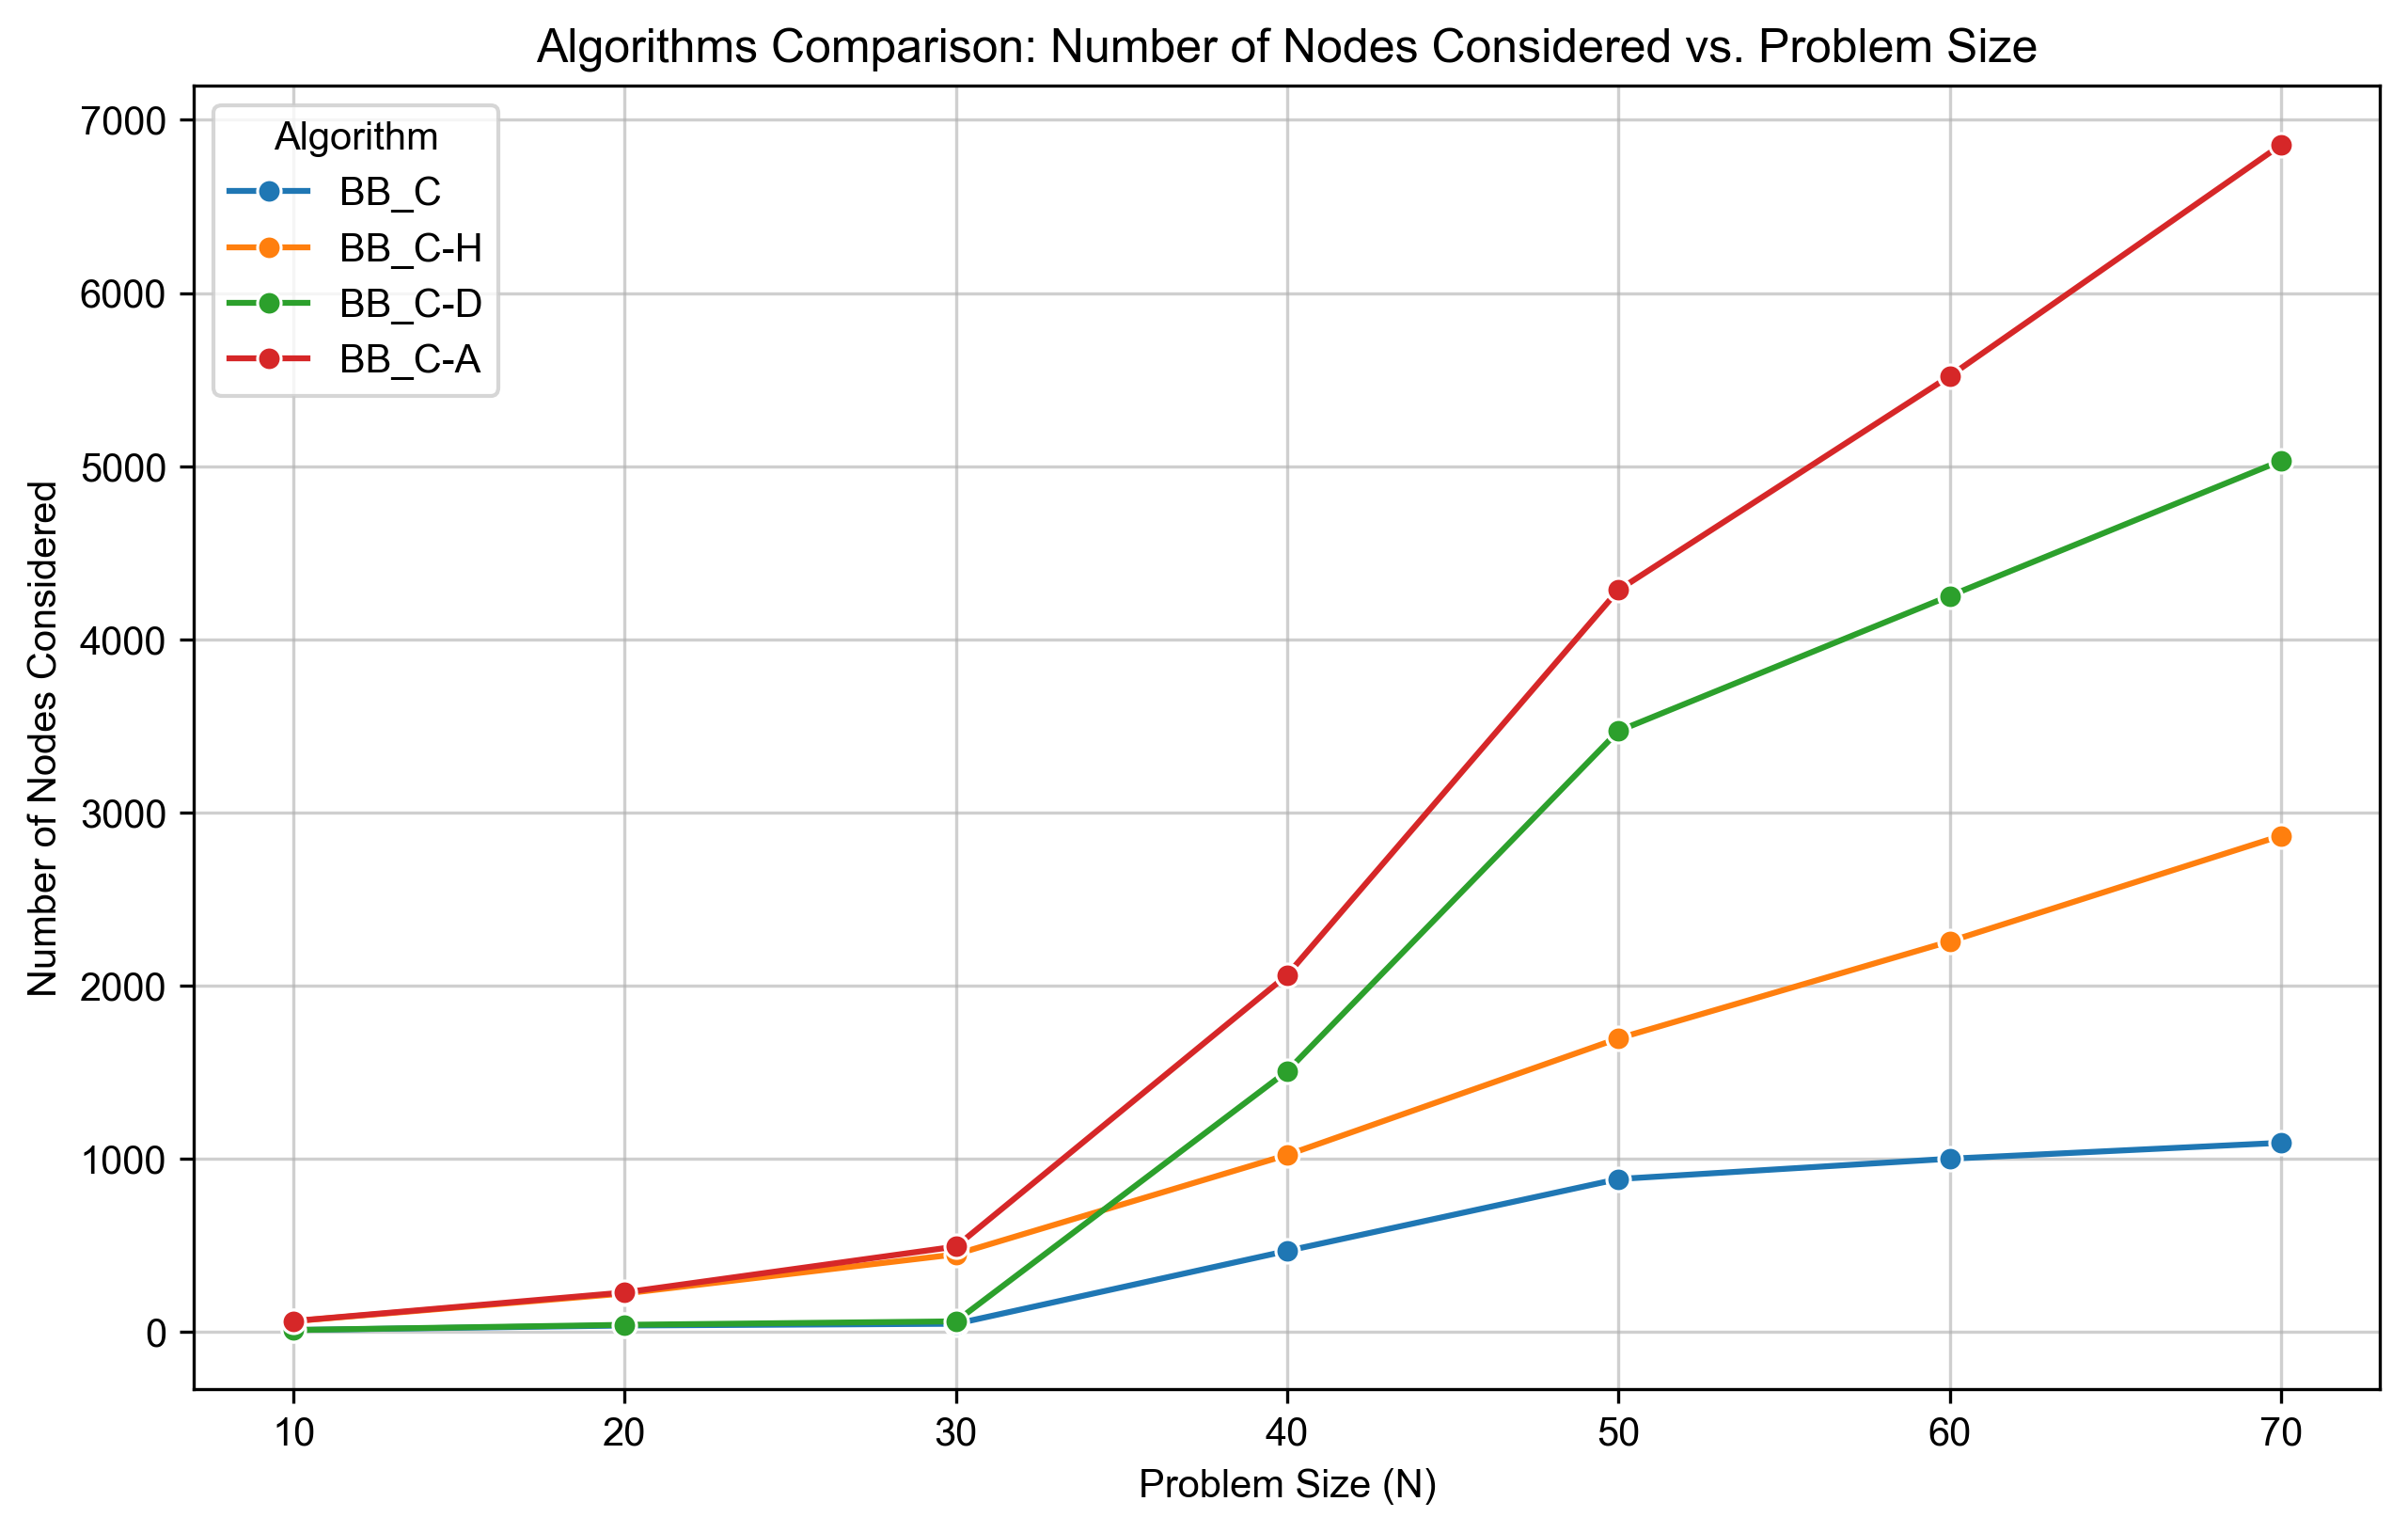

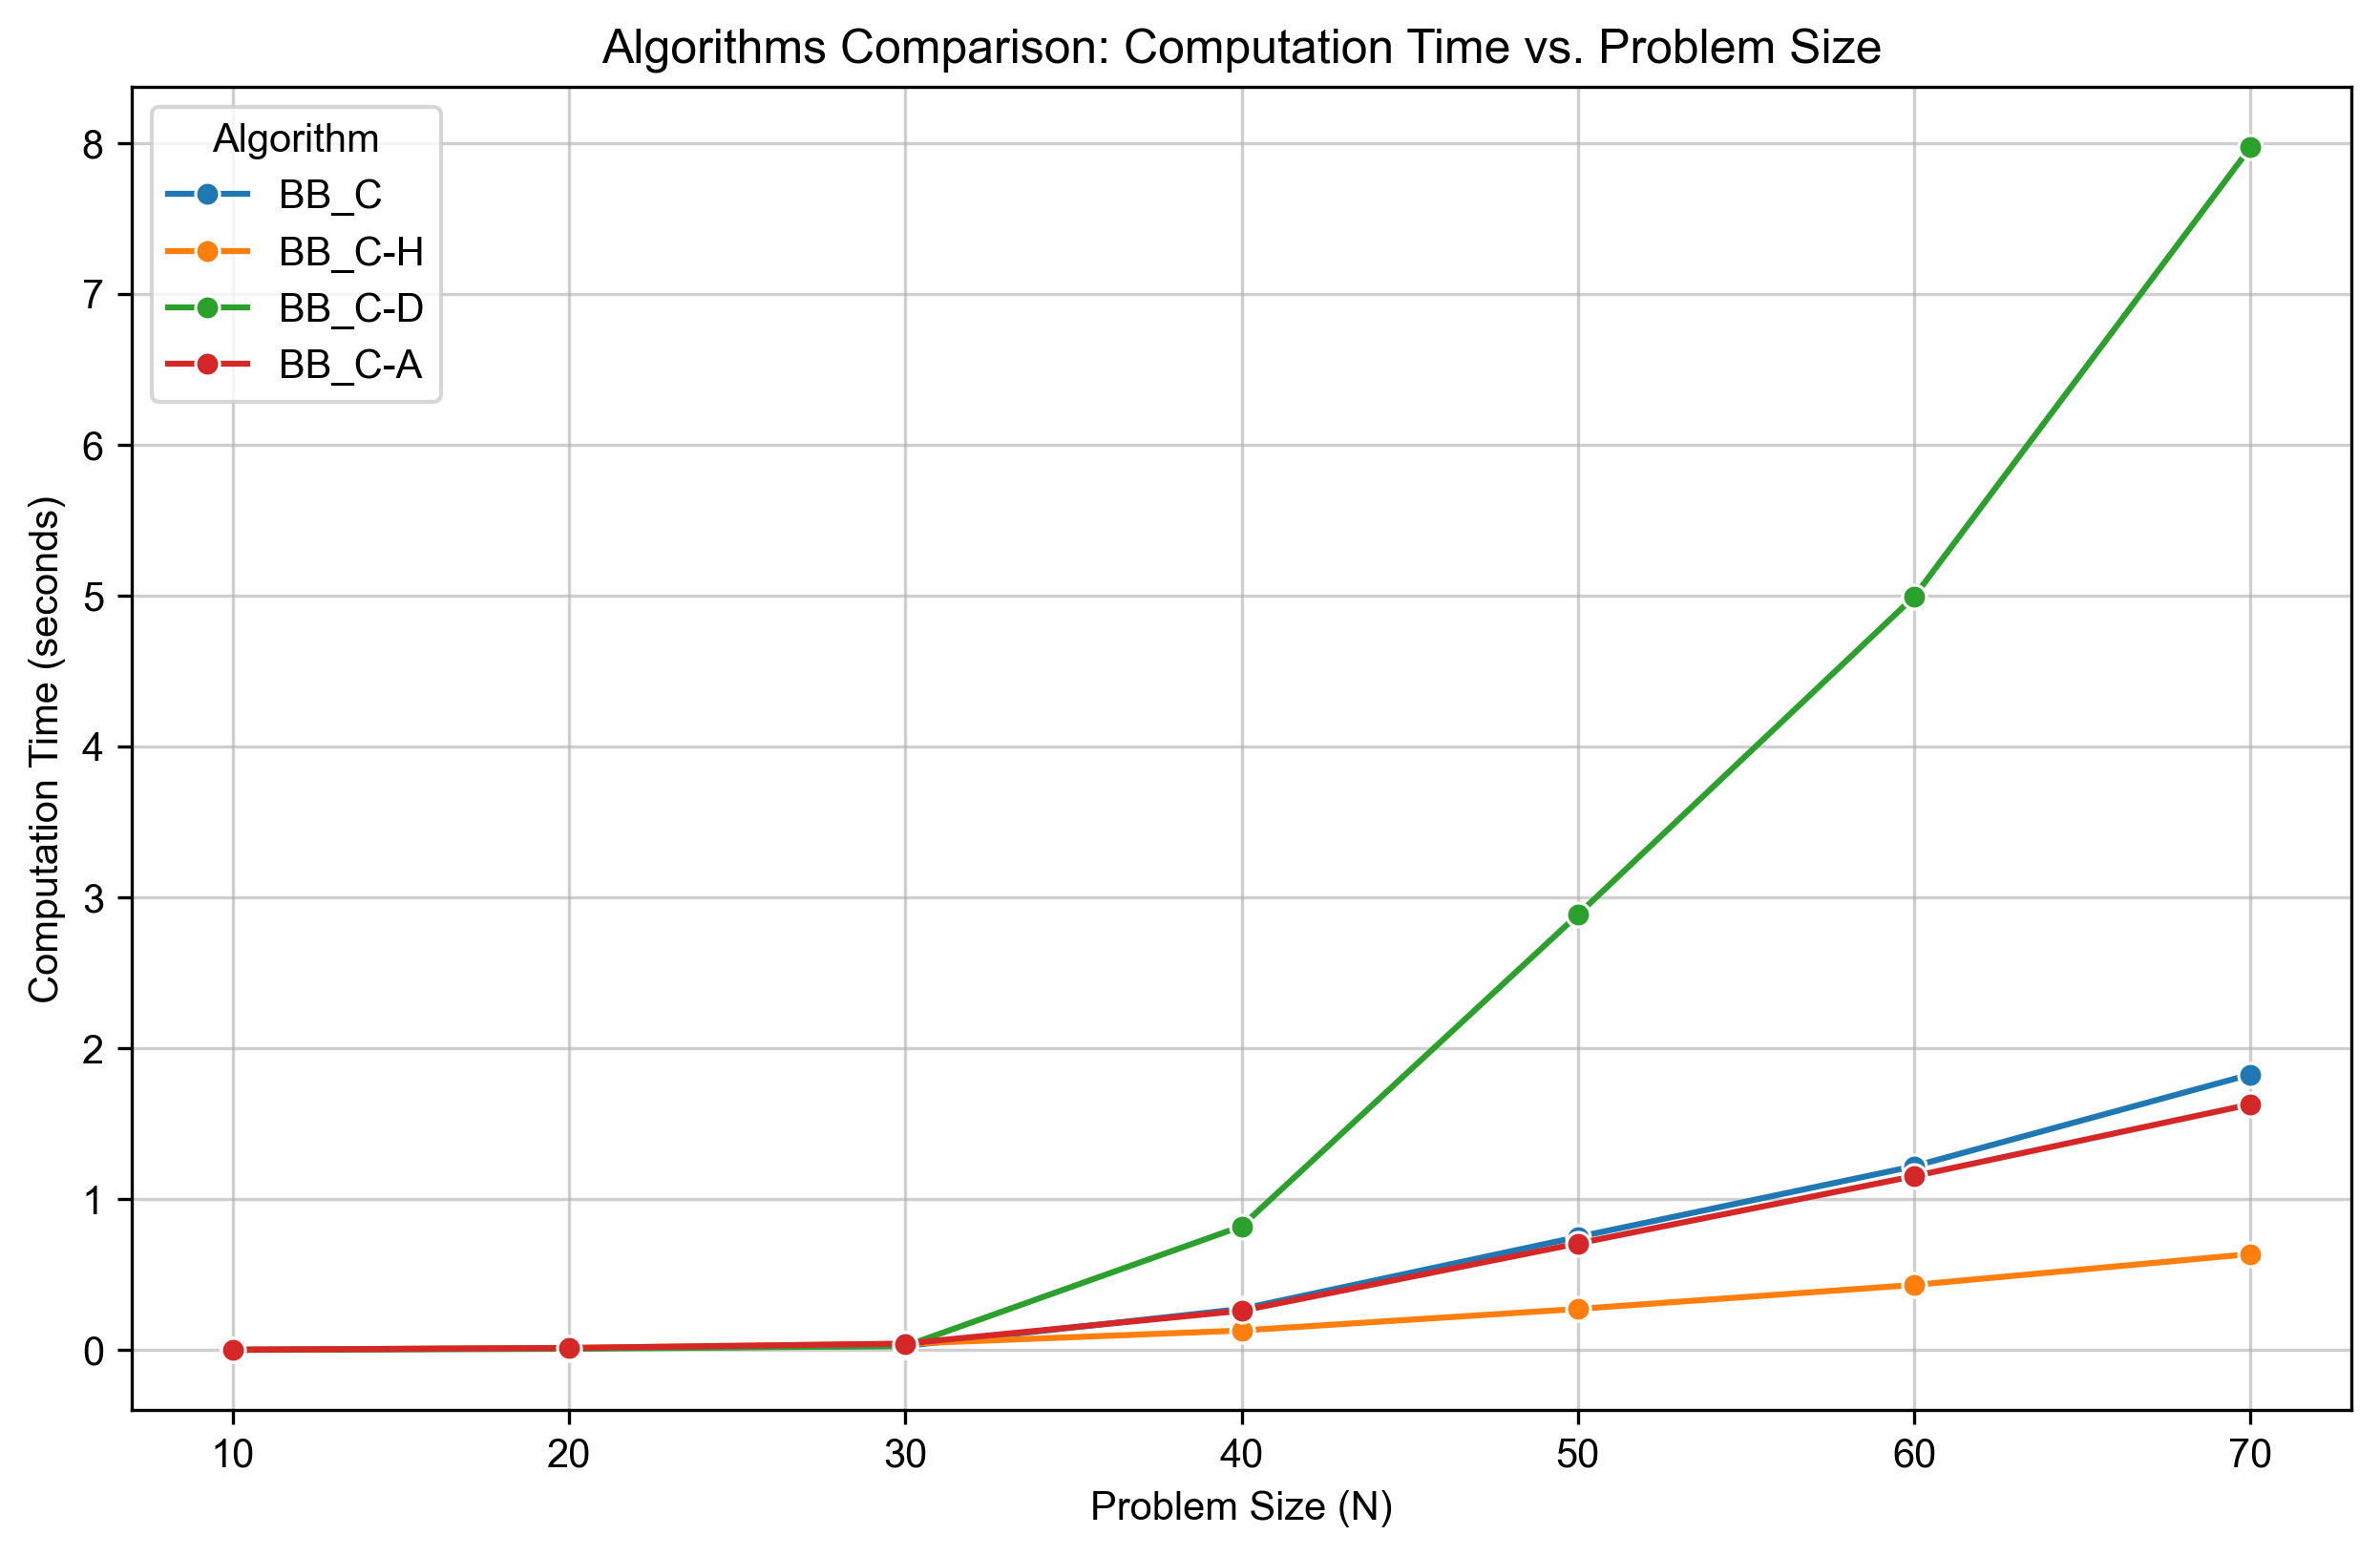

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 定義檔案名稱
file_name = "result_csv/algorithm_performance_data.csv"

# 1. 讀取資料
try:
    df = pd.read_csv(file_name)
    # 將 Problem Size 轉換為字串，確保繪圖時 X 軸的間隔是均勻的
    df['Problem Size'] = df['Problem Size'].astype(str)
except FileNotFoundError:
    print(f"錯誤：找不到檔案 {file_name}。請確認檔案是否存在於當前目錄。")
    exit()

# --- 繪圖 1: Number of Nodes Considered (考慮到的節點數) ---
plt.figure(figsize=(10, 6), dpi=300)
sns.lineplot(
    data=df,
    x='Problem Size',
    y='Number of Nodes Considered',
    hue='Algorithms',
    marker='o',
    errorbar=None
)
plt.title('Algorithms Comparison: Number of Nodes Considered vs. Problem Size')
plt.xlabel('Problem Size (N)')
plt.ylabel('Number of Nodes Considered')
plt.grid(True, which="major", ls="-", alpha=0.6)
plt.legend(title='Algorithm')
path = 'result_fig/Nodes_vs_Size.png'
plt.savefig(path)
plt.show() # 顯示圖表 1

# --- 繪圖 2: Computation Time (計算時間) ---
plt.figure(figsize=(10, 6), dpi=300)
sns.lineplot(
    data=df,
    x='Problem Size',
    y='Computation Time',
    hue='Algorithms',
    marker='o',
    errorbar=None
)
plt.title('Algorithms Comparison: Computation Time vs. Problem Size')
plt.xlabel('Problem Size (N)')
plt.ylabel('Computation Time (seconds)')
plt.grid(True, which="major", ls="-", alpha=0.6)
plt.legend(title='Algorithm')
path = 'result_fig/Time_vs_Size.png'
plt.savefig(path)
plt.show() # 顯示圖表 2

In [96]:
import matplotlib.pyplot as plt

jobs_list = Data_Load()
x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
y_time = []
y_time_p = []

for xx in x:
    current_jobs = jobs_list[:xx]
    _, Performance_Measures = BB_C(current_jobs)
    y_time.append(Performance_Measures['Time'])
    _, Performance_Measures = BB_C_P(current_jobs)
    y_time_p.append(Performance_Measures['Time'])

output_file_name = "result_csv/bb_c_performance_data.csv"

data = {
    'Problem Size': x,
    'BB_C Computation Time (s)': y_time,
    'BB_C (PRFT) Computation Time (s)': y_time_p
}
df = pd.DataFrame(data)

df.to_csv(output_file_name, index=False)

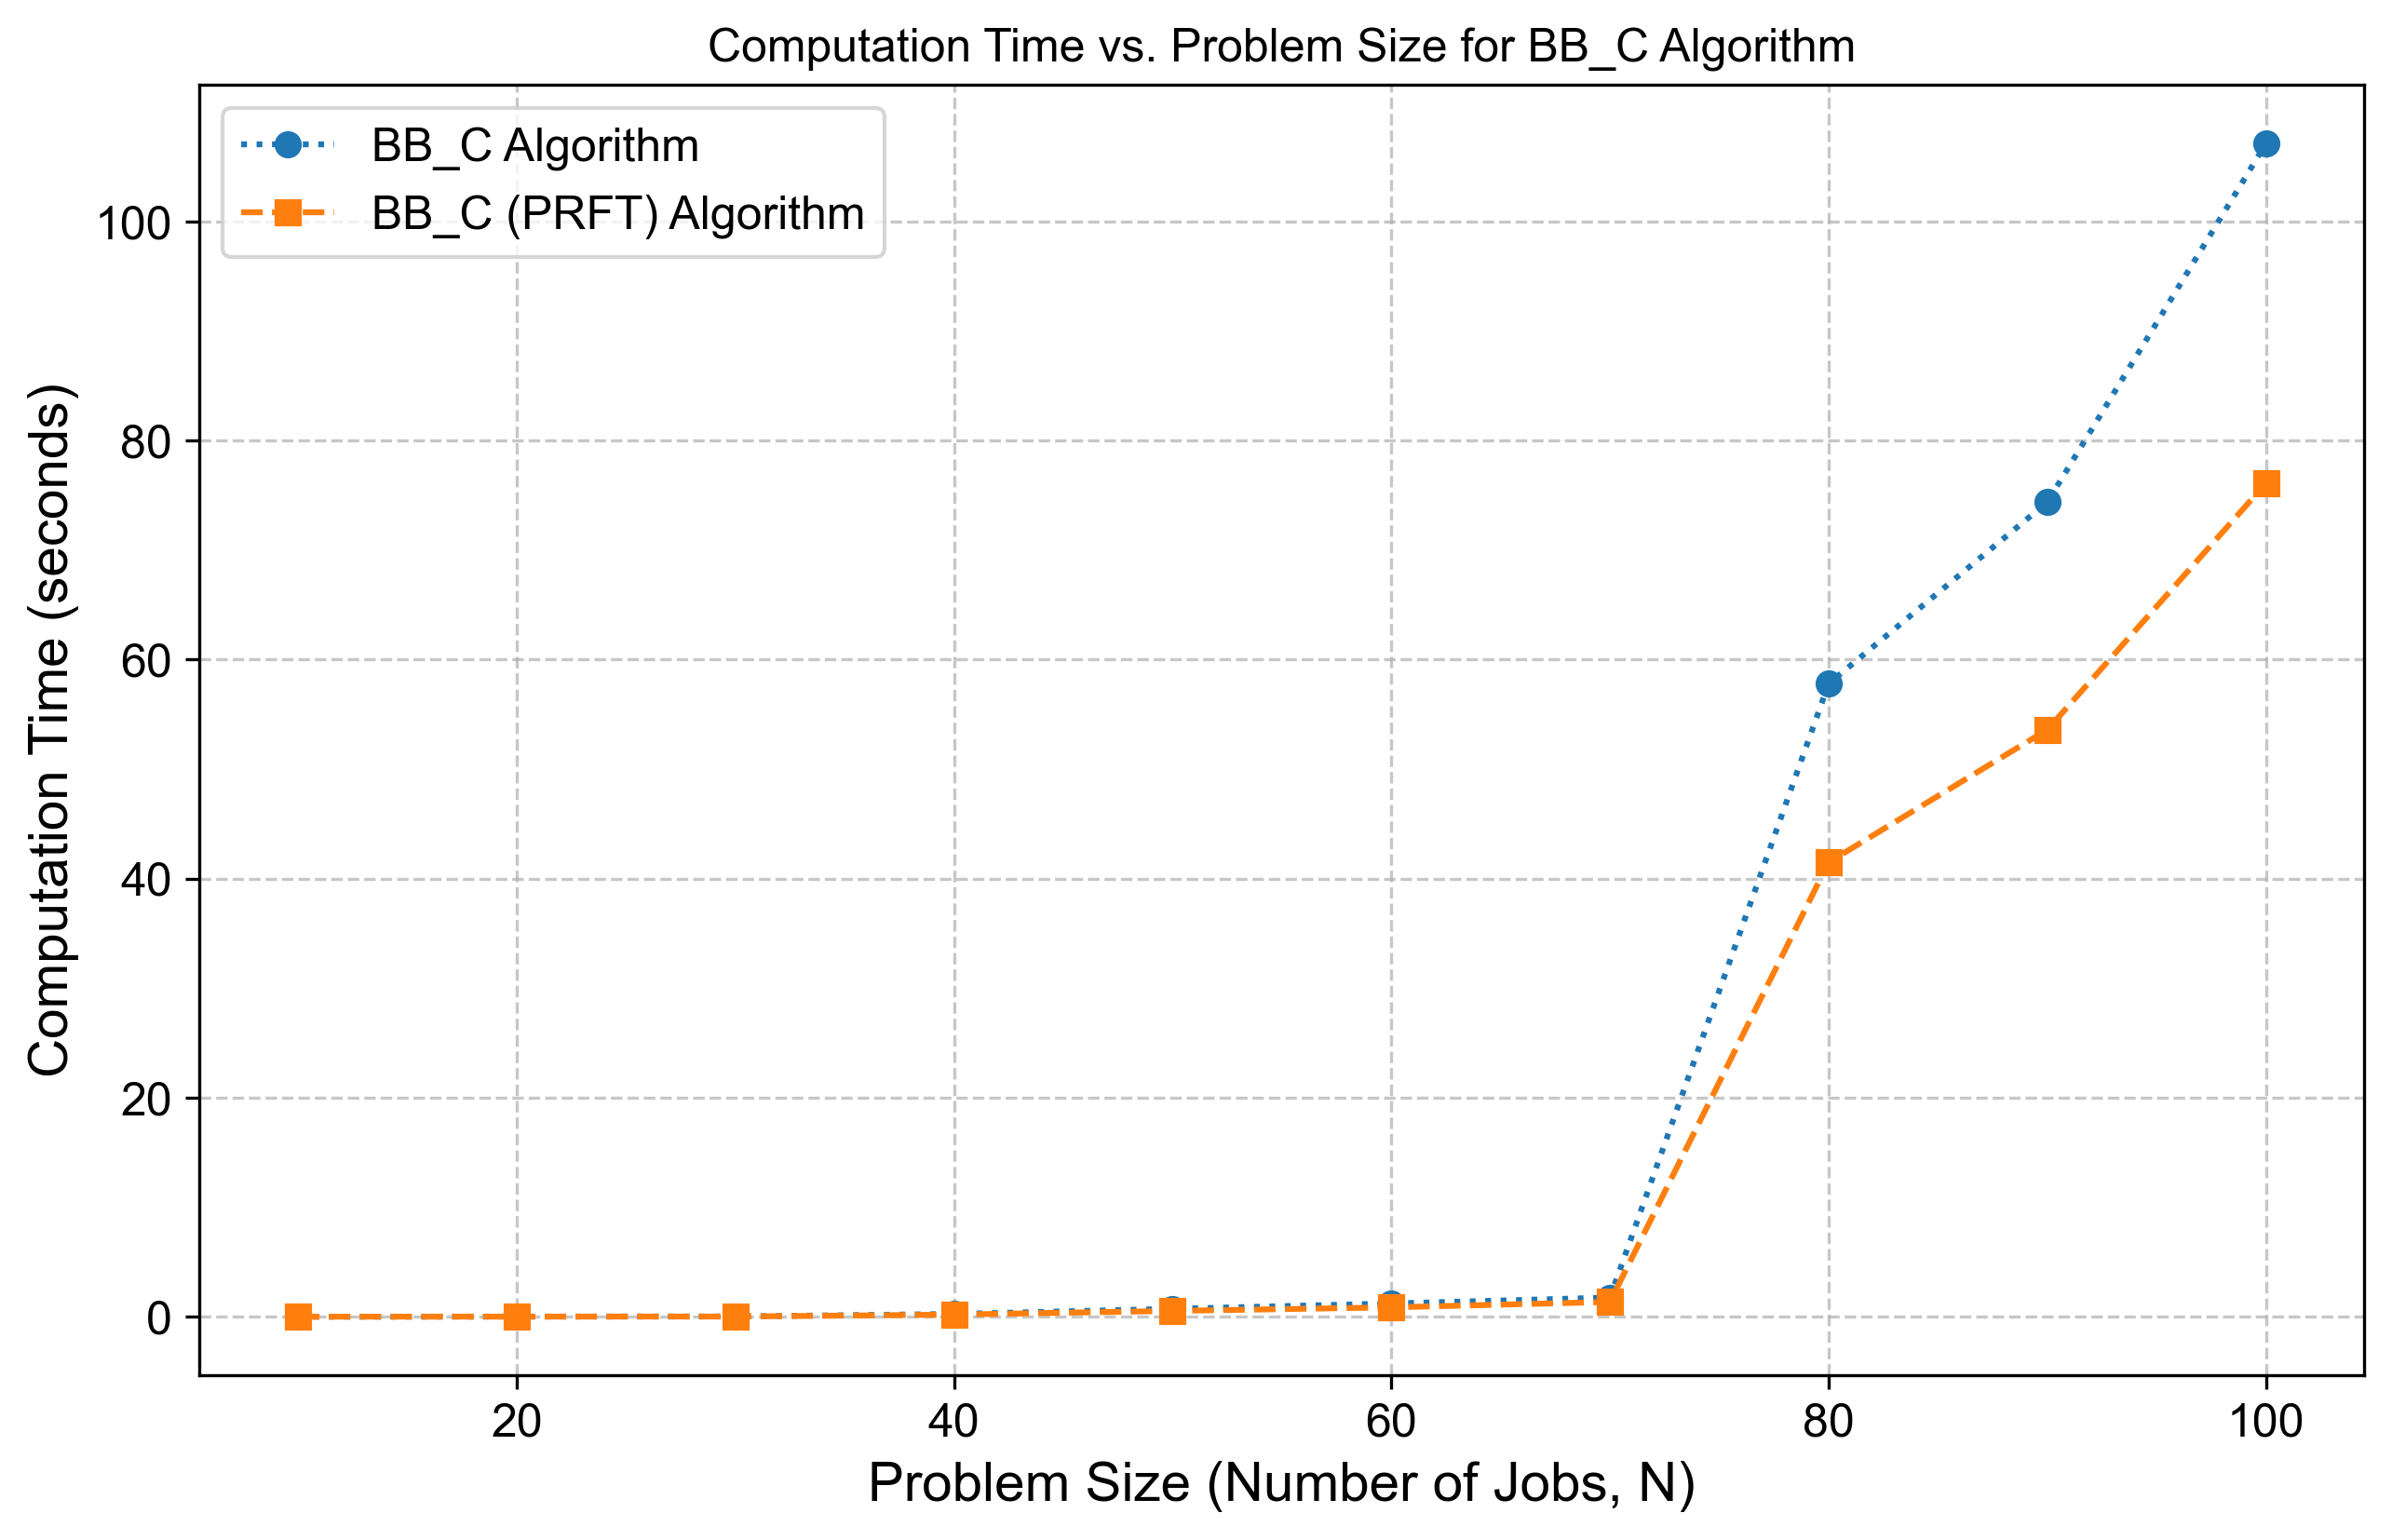

In [ ]:
file_name = "result_csv/bb_c_performance_data.csv"

try:
    df = pd.read_csv(file_name)
    x = df['Problem Size']
    y_time = df['BB_C Computation Time (s)']
    y_time_p = df['BB_C (PRFT) Computation Time (s)']
    df['Problem Size'] = df['Problem Size'].astype(str)
except FileNotFoundError:
    print(f"錯誤：找不到檔案 {file_name}。請確認檔案是否存在於當前目錄。")
    exit()


plt.figure(figsize=(10, 6), dpi=300)
plt.plot(x, y_time, marker='o', linestyle=':', label='BB_C Algorithm')
plt.plot(x, y_time_p, marker='s', linestyle='--', label='BB_C (PRFT) Algorithm')
plt.title('Computation Time vs. Problem Size for BB_C Algorithm')
plt.xlabel('Problem Size (Number of Jobs, N)', fontsize=14)
plt.ylabel('Computation Time (seconds)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(loc='upper left', fontsize=12)
path = 'result_fig/BB_C_Time_vs_Size.png'
plt.savefig(path)
plt.show()

In [94]:
jobs_list = Data_Load()
n = 100
jobs_list = jobs_list[:n+1]

print(TCT_Objective(APRTF_Algorithm(jobs_list, 0)))
print(TCT_Objective(SRPT_Algorithm(jobs_list, 0)))
print("="*60)
S, Performance_Measures = BB_C_P(jobs_list)
print(Performance_Measures)
print("="*60)
print(TCT_Objective(S))

180302
179452
{'NC': 38990, 'NG': 56999, 'MaxSizePQ': 38321, 'Time': '74.602'}
179550
